# Hello!

This notebook is used to run all the code, including training, making of predictions, and visualizations.

## Runtime set-up
The following has to be done before anything else is run. We are going to correctly set environmental settings and import Tensorflow.

In [1]:
import os

# Must be set BEFORE importing tensorflow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"          # suppresses INFO+WARNING from C++ side
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

import tensorflow as tf

# Disable XLA JIT explicitly
tf.config.optimizer.set_jit(False)
tf.debugging.set_log_device_placement(False)

# Optional: GPU memory growth (prevents TF from grabbing all VRAM at once) (I reccommend doing this, may encounter memory issues without)
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"Could not set memory growth for {gpu}: {e}")

print("XLA JIT:", tf.config.optimizer.get_jit())
print("GPUs:", gpus)


XLA JIT: 
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


The following block will print what version of Tensorflow has been importated and what GPU devices you are running on, if any.

In [2]:
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Importing functions
Below is where we import the functions needed for training and for predictions

### Importing source files:

In [3]:
import sys
sys.path.insert(0, os.path.abspath("."))  # so `source/` package is importable

import importlib

from pathlib import Path
from datetime import datetime
from tensorflow import keras
from matplotlib.ticker import MaxNLocator


In [4]:
# Source files! (import as modules) 
import source.import_datasets as idm
import source.build_datasets as bd
import source.mapping as ma
import source.callbacks as cb
import source.train_utils as tu
import source.validation_util as vu
import source.run_config as rc
import source.loss_curves as lc

import source.metrics as met

import source.plotting_metrics as pm


import source.predict_full_simulation_metrics as psm

import source.overlay_prediction_on_microstructure as opm

import source.plot_pred_vs_gt_contours as pgc

import source.plot_compare_f1_full_simulation as pcfs

import source.summarize_total_metrics_across_simulations as stmas

import source.overlay_prediction_on_microstructure_opaque as opmo


# If you edit .py source files, rerun THIS cell to pick up changes
importlib.reload(idm)
importlib.reload(bd)
importlib.reload(ma)
importlib.reload(cb)
importlib.reload(tu)
importlib.reload(vu)
importlib.reload(rc)
importlib.reload(lc)
importlib.reload(met)
importlib.reload(pm)
importlib.reload(psm)
importlib.reload(opm)
importlib.reload(pgc)
importlib.reload(pcfs)
importlib.reload(stmas)
importlib.reload(opmo)

<module 'source.overlay_prediction_on_microstructure_opaque' from '/scratch/gilbreth/kmartinu/toGit_MICROSTRUCTURE_ML/ALL_INPUTS/CODE/source/overlay_prediction_on_microstructure_opaque.py'>

# RUN TRAINING

Different versions of the model can be trained. Options are the base model, and inclusion of three other variables, one at a time (pressure, von mises stress, strain energy density).

Base model: 1  
With pressure: 2  
With von mises stress: 3  
With strain energy density: 4  

### SETTINGS TO CHANGE

In [5]:
# =========================
# SELECT MODE FOR TRAINING
# =========================
MODE = 1  # 1=base, 2=+pressure, 3=+vonmises, 4=+SED

# =========================
# PATH WHERE DATA IS
# =========================

DATA_ROOT = Path("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/DATASET/GIT_DATASET")

# =========================
# PATH WHERE MODELS SHOULD BE SAVED
# =========================
MODEL_ROOT = Path("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FINAL_GC/BASE")

# =========================
# INPUTS INTO BASE MODEL
# =========================
cfg = {
    "feature_cols": ("x","y","ux","uy","Gc","fracture_mask"),
    "extra": None,
    
    # velocity comes from folder name, not from CSV columns
    "add_velocity": True,
    "velocity_scale": 1.0 / 1000.0,

}

### MAPPING AND DATA BUILDING
The following code does the mapping process and splitting of data into train, test, and validation sets. The mapping can take several minutes even with GPUs, I've found anywhere from 10-20 minutes.

In [6]:
cfg = rc.build_cfg(MODE, include_extra_in_feature_cols=True)

cfg["add_velocity"] = True
cfg["velocity_scale"] = 1.0 / 1000.0

# -------------------------
# OUTPUT PATHS (MODEL/<RUN_TAG>/...)
# -------------------------
prefix = (cfg.get("extra") or "base").lower().replace(" ", "")

RUN_TAG = f"{prefix}_{datetime.now():%Y%m%d_%H%M%S}_LARGER_RANGE"
RUN_DIR = MODEL_ROOT / RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = RUN_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CSV_LOG_PATH = RUN_DIR / "training_log.csv"

print("RUN_TAG:", RUN_TAG)
print("extra_var:", cfg["extra"])
print("feature_cols:", cfg["feature_cols"])
print("add_velocity:", cfg.get("add_velocity", False))
print(
    "velocity_scale:", cfg.get("velocity_scale", None),
    "(e.g., V100 -> {:.3f})".format(100.0 * cfg.get("velocity_scale", 0.0))
    if cfg.get("velocity_scale") is not None else ""
)

print("RUN_DIR:", RUN_DIR)
print("Checkpoint dir:", CKPT_DIR)
print("CSV log path:", CSV_LOG_PATH)
print("DATA_ROOT:", DATA_ROOT)

# -------------------------
# Shared run settings
# -------------------------
BATCH_SIZE = 5
SEQ_LEN = 10
VAL_FRAC = 0.1  # What percentage of training data to set aside for validation

# 1) Build raw datasets (point-wise windows)
datasets_raw = bd.make_datasets(
    data_root=DATA_ROOT,
    feature_cols=cfg["feature_cols"],
    batch_size=BATCH_SIZE,
    sequence_length=SEQ_LEN,
    drop_first_csv=True,
    print_run_stats=False,
    stats_max_files_train=1,
    stats_max_files_test=None,
    add_velocity=cfg["add_velocity"],
    velocity_scale=cfg["velocity_scale"],
)

# 1b) Create validation split from the TRAIN dataset
train_raw, val_raw, total_batches, val_batches = vu.split_train_val_by_batches(
    datasets_raw["train"],
    validation_fraction=VAL_FRAC,
    verbose=True,
)

datasets_raw = dict(datasets_raw)   # safe copy
datasets_raw["train"] = train_raw
datasets_raw["val"]   = val_raw

# 2) Map ALL datasets that exist in datasets_raw (train/val/test...)
mapping_cfg = ma.MappingConfig(
    sequence_length=SEQ_LEN,
    uxuy_scale=1e4,
    binarize_masks=True,
    mask_thresh=0.5,
    binarize_after_avg=False,
)

datasets_img, grid, Cin = ma.map_existing_datasets(
    datasets_raw=datasets_raw,
    mapping_cfg=mapping_cfg,
    feature_cols=cfg["feature_cols"],
    extra_var=cfg["extra"],      # None/pressure/vonmises/SED
    grid_source_key="train",
    add_velocity=cfg["add_velocity"],
)

print(f"Mapped grid: H={grid.H}, W={grid.W} | Model Cin={Cin}")

train_dataset_img = datasets_img["train"]
val_dataset_img   = datasets_img["val"]

RUN_TAG: base_20260604_144123_LARGER_RANGE
extra_var: None
feature_cols: ('x', 'y', 'ux', 'uy', 'Gc', 'fracture_mask')
add_velocity: True
velocity_scale: 0.001 (e.g., V100 -> 0.100)
RUN_DIR: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FINAL_GC/BASE/base_20260604_144123_LARGER_RANGE
Checkpoint dir: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FINAL_GC/BASE/base_20260604_144123_LARGER_RANGE/checkpoints
CSV log path: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FINAL_GC/BASE/base_20260604_144123_LARGER_RANGE/training_log.csv
DATA_ROOT: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/DATASET/GIT_DATASET
[trainDS] Found 5511 CSV files under /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/DATASET/GIT_DATASET/trainDS
[trainDS] Detected velocities (scaled) in '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/DATASET/GIT_DATASET/trainDS': [0.1, 0.2, 0.4, 1.0] (count=4)
[trainDS]   F_MS201_V1000_out -> 1.0
[trainDS]   F_M

Building can take several minutes even with GPUs, 10-20 minutes

Next block calls the source file that is used to make the ML framework.

In [7]:
# 3) Build model with computed Cin
model_cfg = ma.ModelConfig(
    sequence_length=SEQ_LEN,
    dropout=0.1,
    lr=1e-4,
    clipnorm=1.0,
    Cin=Cin,
    seed=42,
)

model = ma.build_convlstm_model(model_cfg, grid)
model.summary()

Model: "microML_convlstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq_in (InputLayer)             │ (None, 10, 321, 161,   │             0 │
│                                 │ 7)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm1 (ConvLSTM2D)             │ (None, 10, 321, 161,   │       622,592 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 321, 161,   │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm2 (ConvLSTM2D)             │ (None, 10, 321, 161,   │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 321, 161,   │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 322, 162,   │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 161, 81,    │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm3 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 161, 81,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm4 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 161, 81,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm5 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 161, 81,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm6 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 161, 81,    │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clstm7 (ConvLSTM2D)             │ (None, 10, 161, 81,    │     1,180,160 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 161, 81,    │           51

 Total params: 7,744,321 (29.54 MB)

 Trainable params: 7,742,529 (29.54 MB)

 Non-trainable params: 1,792 (7.00 KB)

### Check inputs and output (ML target) for training

The following block can be used to double check the type of model that is going to be trained (ex. base model, pressure, von mises stress, SED)  
Can take a minute to run

In [8]:
print("\n===== DATASET INSPECTION =====")

# ----- print channel names/order (expected mapped order) -----
print("\n=== CHANNEL ORDER (expected mapped input) ===")
mapped_channel_names = ["fracture_mask", "ux", "uy", "Gc"]

if cfg.get("extra") is not None:
    mapped_channel_names.append(cfg["extra"])

if cfg.get("add_velocity", False):
    mapped_channel_names.append("velocity")

mapped_channel_names.extend(["x_norm", "y_norm"])

for i, ch in enumerate(mapped_channel_names):
    print(f"{i}: {ch}")


# Helper to get mapped-channel index safely
def _mapped_ch_idx(name):
    if name in mapped_channel_names:
        return mapped_channel_names.index(name)
    return None


for X_batch, y_batch in train_dataset_img.take(1):
    print("\n=== BATCH SHAPES ===")
    print("X_batch shape:", X_batch.shape)   # (B, T, H, W, Cin)
    print("y_batch shape:", y_batch.shape)   # (B, T, H, W, 1)
    print("X dtype:", X_batch.dtype)
    print("y dtype:", y_batch.dtype)

    # Inspect first sample in batch
    X0 = X_batch[0]
    y0 = y_batch[0]

    print("\n--- First sample ---")
    print("X0 shape:", X0.shape)
    print("y0 shape:", y0.shape)

    print("Min/Max X:", tf.reduce_min(X0).numpy(), tf.reduce_max(X0).numpy())
    print("Min/Max y:", tf.reduce_min(y0).numpy(), tf.reduce_max(y0).numpy())

    # ----- per-channel stats (first timestep) -----
    print("\n=== CHANNEL STATS (first sample, t=0) ===")
    Xt0 = X0[0]
    Cin = Xt0.shape[-1]

    for c in range(Cin):
        ch_min = tf.reduce_min(Xt0[..., c]).numpy()
        ch_max = tf.reduce_max(Xt0[..., c]).numpy()
        ch_mean = tf.reduce_mean(Xt0[..., c]).numpy()
        name = mapped_channel_names[c] if c < len(mapped_channel_names) else f"ch{c}"
        print(f"{c:>2} ({name:>12}): min={ch_min: .4e}  max={ch_max: .4e}  mean={ch_mean: .4e}")

    print("\n=== EXTRA DEBUG CHECKS (first sample, t=0) ===")

    # 1) Is pressure binary or continuous?
    p_idx = _mapped_ch_idx("pressure")
    if p_idx is not None:
        p = Xt0[..., p_idx]
        uniq = tf.unique(tf.reshape(tf.cast(p, tf.float32), [-1]))[0]
        print(f"pressure channel index: {p_idx}")
        print("pressure unique count:", int(uniq.shape[0]))
        print("pressure first 20 unique values:", uniq.numpy()[:20])

        p_flat = tf.reshape(p, [-1])
        frac0 = tf.reduce_mean(tf.cast(tf.abs(p_flat - 0.0) < 1e-8, tf.float32)).numpy()
        frac1 = tf.reduce_mean(tf.cast(tf.abs(p_flat - 1.0) < 1e-8, tf.float32)).numpy()
        print(f"pressure fraction exactly 0: {frac0:.4f}, exactly 1: {frac1:.4f}")
    else:
        print("pressure not present in mapped input.")

    # 2) Velocity check
    v_idx = _mapped_ch_idx("velocity")
    if v_idx is not None:
        v = Xt0[..., v_idx]
        uniq_v = tf.unique(tf.reshape(tf.cast(v, tf.float32), [-1]))[0]
        print(f"velocity channel index: {v_idx}")
        print("velocity unique count:", int(uniq_v.shape[0]))
        print("velocity unique values:", uniq_v.numpy()[:20])
    else:
        print("velocity not present in mapped input.")

    # 3) How much of the grid is 'material' vs background?
    gc_idx = _mapped_ch_idx("Gc")
    if gc_idx is not None:
        material_frac = tf.reduce_mean(tf.cast(tf.abs(Xt0[..., gc_idx]) > 1e-12, tf.float32)).numpy()
        print(f"Gc channel index: {gc_idx}")
        print("fraction of grid with |Gc| > 1e-12 (material proxy):", material_frac)
    else:
        print("Gc not found in mapped input; cannot compute material proxy fraction.")

    break

print("\n===== MODEL INPUT EXPECTATION =====")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


===== DATASET INSPECTION =====

=== CHANNEL ORDER (expected mapped input) ===
0: fracture_mask
1: ux
2: uy
3: Gc
4: velocity
5: x_norm
6: y_norm

=== BATCH SHAPES ===
X_batch shape: (5, 10, 321, 161, 7)
y_batch shape: (5, 10, 321, 161, 1)
X dtype: <dtype: 'float32'>
y dtype: <dtype: 'float32'>

--- First sample ---
X0 shape: (10, 321, 161, 7)
y0 shape: (10, 321, 161, 1)
Min/Max X: -1.570109e-05 1.0
Min/Max y: 0.0 0.0

=== CHANNEL STATS (first sample, t=0) ===
 0 (fracture_mask): min= 0.0000e+00  max= 0.0000e+00  mean= 0.0000e+00
 1 (          ux): min=-9.8967e-19  max= 1.2950e-02  mean= 3.2230e-04
 2 (          uy): min=-4.4109e-06  max= 5.3553e-06  mean=-8.5349e-11
 3 (          Gc): min= 2.4109e-02  max= 9.9437e-01  mean= 5.6028e-01
 4 (    velocity): min= 1.0000e-01  max= 1.0000e-01  mean= 1.0000e-01
 5 (      x_norm): min= 0.0000e+00  max= 1.0000e+00  mean= 5.0000e-01
 6 (      y_norm): min= 0.0000e+00  max= 1.0000e+00  mean= 5.0000e-01

=== EXTRA DEBUG CHECKS (first sample, t=0) 

### TRAIN FROM BEGINNING

In [ ]:
#If you get OOM memory issues, can run "nvidia-smi" in a terminal to see if there are other sessions taking up memory. 
#from the terminal, you can cancel sessions and can run the following command to see your current session id
#so that you don't cancel this one:

#os.getpid()

In [29]:
# =========================
# SELECT HOW MANY EPOCHS YOU WANT TO TRAIN TO
# =========================

EPOCHS_TOTAL = 130

# =========================
# SELECT HOW MANY EPOCHS TO START FROM (IF YOU'RE TRAINING FROM A CHECKPOINT)
# =========================

INITIAL_EPOCH = 127     

# =========================
# PATH FOR RE-LOADING AN ALREADY TRAINED MODEL
# =========================

#MODEL_PATH = str(CKPT_DIR / "ep050-val0.0017.keras") 

In [ ]:
model, history, info = tu.train_model(
    model=model,                          # the model you already built from mapping.py
    train_dataset_img=train_dataset_img,
    val_dataset_img=val_dataset_img,
    run_dir=RUN_DIR,                      # from your MODE/path block
    epochs_total=EPOCHS_TOTAL,
    initial_epoch=0,
    model_path=None,             
)

print(info)

Epoch 1/130
770/770 ━━━━━━━━━━━━━━━━━━━━ 1003s 1s/step - binary_accuracy: 0.9953 - loss: 0.0177 - precision_1: 0.7824 - recall_1: 0.8520 - val_binary_accuracy: 0.9984 - val_loss: 0.0049 - val_precision_1: 0.9812 - val_recall_1: 0.8651 - learning_rate: 1.0000e-04 - epoch_time_sec: 1002.5207
Epoch 2/130
770/770 ━━━━━━━━━━━━━━━━━━━━ 941s 1s/step - binary_accuracy: 0.9988 - loss: 0.0037 - precision_1: 0.9678 - recall_1: 0.9286 - val_binary_accuracy: 0.9988 - val_loss: 0.0038 - val_precision_1: 0.9761 - val_recall_1: 0.8993 - learning_rate: 1.0000e-04 - epoch_time_sec: 940.7044
Epoch 3/130
770/770 ━━━━━━━━━━━━━━━━━━━━ 919s 1s/step - binary_accuracy: 0.9990 - loss: 0.0028 - precision_1: 0.9725 - recall_1: 0.9483 - val_binary_accuracy: 0.9990 - val_loss: 0.0032 - val_precision_1: 0.9669 - val_recall_1: 0.9393 - learning_rate: 1.0000e-04 - epoch_time_sec: 919.2948
Epoch 4/130
770/770 ━━━━━━━━━━━━━━━━━━━━ 937s 1s/step - binary_accuracy: 0.9994 - loss: 0.0018 - precision_1: 0.9781 - recall_1: 0.

### TRAIN FROM CHECKPOINT

In [ ]:
model = keras.models.load_model("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FINAL_GC/BASE/base_20260412_002238_LARGER_RANGE/checkpoints/ep130-val0.0001.keras")





In [ ]:
opt = keras.optimizers.Adam(1e-4, clipnorm=1.0)
model.compile(optimizer=opt, 
                         loss="binary_crossentropy",
                          metrics=[
        tf.keras.metrics.BinaryAccuracy(threshold=0.5),
        tf.keras.metrics.Precision(thresholds=0.5),
        tf.keras.metrics.Recall(thresholds=0.5)
    ])

In [30]:
model, history, info = tu.train_model(
    model=model,                          # can pass the existing model; will be replaced by loaded one
    train_dataset_img=train_dataset_img,
    val_dataset_img=val_dataset_img,
    run_dir=RUN_DIR,
    epochs_total=EPOCHS_TOTAL,
    initial_epoch=INITIAL_EPOCH,
    model_path="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/FINAL_GC/BASE/base_20260412_002238_LARGER_RANGE/checkpoints/ep127-val0.0001.keras"

)
print(info)

Epoch 128/130
770/770 ━━━━━━━━━━━━━━━━━━━━ 1042s 1s/step - binary_accuracy: 0.9999 - loss: 1.6374e-04 - precision_9: 0.9979 - recall_9: 0.9967 - val_binary_accuracy: 0.9999 - val_loss: 1.3544e-04 - val_precision_9: 0.9985 - val_recall_9: 0.9963 - learning_rate: 1.0000e-04 - epoch_time_sec: 1042.0163
Epoch 129/130
770/770 ━━━━━━━━━━━━━━━━━━━━ 916s 1s/step - binary_accuracy: 0.9999 - loss: 1.5423e-04 - precision_9: 0.9980 - recall_9: 0.9969 - val_binary_accuracy: 0.9999 - val_loss: 1.3571e-04 - val_precision_9: 0.9975 - val_recall_9: 0.9972 - learning_rate: 1.0000e-04 - epoch_time_sec: 916.2579
Epoch 130/130
770/770 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9999 - loss: 1.7102e-04 - precision_9: 0.9979 - recall_9: 0.9968
Epoch 130: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
770/770 ━━━━━━━━━━━━━━━━━━━━ 934s 1s/step - binary_accuracy: 0.9999 - loss: 1.6073e-04 - precision_9: 0.9979 - recall_9: 0.9968 - val_binary_accuracy: 0.9999 - val_loss: 1.6920e-04 -

# RUN PREDICTIONS

In [9]:
print("Available datasets:", datasets_img.keys())

Available datasets: dict_keys(['train', 'test_MS206_V100', 'test_MS206_V200', 'test_MS206_V400', 'test_MS206_V1000', 'test_MS210_V400', 'test_PBX1_V400_true', 'test_PBX_2_V400', 'test_MS5_V150ms_inc', 'test_MS5_V400ms', 'test_emergency_horizontal', 'test_horizontal_layers_3', 'test_horizontal_layers_4', 'test_inclusions_1_2', 'test_inclusions_2_2', 'test_inclusions_3_2', 'test_inclusions_true_V400', 'val'])


In [7]:
# Choose which test set
TEST_NAME = "test_MS206_V1000"
ds = datasets_img[TEST_NAME]

# Choose output directory
#out_dir = f"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/{RUN_TAG}/{TEST_NAME}"


## Load model

Load different models here

In [8]:
#FOR BASE
model = keras.models.load_model("/scratch/gilbreth/kmartinu/toGit_MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/BASE/checkpoints/base_ep070-val0.0004.keras")

#FOR PRESSURE
#model = keras.models.load_model("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/PRESSURE/checkpoints/ep130-val0.0001.keras")

#FOR VON MISES
#model = keras.models.load_model("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/VON/checkpoints/ep130-val0.0001.keras")

#FOR SED
#model = keras.models.load_model("/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/SED/checkpoints/ep092-val0.0011.keras")




In [9]:
opt = keras.optimizers.Adam(1e-4, clipnorm=1.0)
model.compile(optimizer=opt, 
                         loss="binary_crossentropy",
                          metrics=[
        tf.keras.metrics.BinaryAccuracy(threshold=0.5),
        tf.keras.metrics.Precision(thresholds=0.5),
        tf.keras.metrics.Recall(thresholds=0.5)
    ])



## Run prediction!

The following block is another print check of what channels are used in the test data set selected

In [240]:
print("Feature columns used for ds_img:")
for i, name in enumerate(cfg["feature_cols"]):
    print(f"  channel {i}: {name}")

for X_batch, y_batch in ds.take(1):
    print("\nOne batch shapes:")
    print("X_batch shape:", X_batch.shape)   # (B,T,H,W,C)
    print("y_batch shape:", y_batch.shape)   # usually (B,T,H,W,1)

Feature columns used for ds_img:
  channel 0: x
  channel 1: y
  channel 2: ux
  channel 3: uy
  channel 4: Gc
  channel 5: fracture_mask
  channel 6: SED

One batch shapes:
X_batch shape: (5, 10, 321, 161, 7)
y_batch shape: (5, 10, 321, 161, 1)


### Autoregressive prediction call

In [10]:
OUT_DIR = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/EXAMPLE_ex/test_MS206_V1000"

In [11]:
df = psm.predict_full_simulation_continuous_ar_with_metrics(
    ds_img=ds,                 # your tf dataset
    model=model,               # your loaded keras model
    out_dir=OUT_DIR,
    threshold=0.5,
    csv_path=os.path.join(OUT_DIR, "per_frame_metrics.csv"),
    gt_threshold=0.5,
    frames_per_ns=10.0,
    fracture_channel_idx=0,    # change if fracture is not channel 0
    max_ar_steps=None,         # or set an integer for a shorter test
)

fracture_channel_idx_eff=0
enforce_no_healing=True


Continuous AR /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/EXAMPLE_ex/test_MS206_V1000: 42it [00:52,  1.25s/it]



Stopping rollout at dataset end because the next batch is smaller (3 instead of 5). Metrics up to this point will still be saved.
Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/EXAMPLE_ex/test_MS206_V1000/bce_over_time.png

Saved 210 frames to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/EXAMPLE_ex/test_MS206_V1000
Saved per-frame metrics CSV to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/EXAMPLE_ex/test_MS206_V1000/per_frame_metrics.csv
Saved BCE plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/EXAMPLE_ex/test_MS206_V1000/bce_over_time.png

TOTAL METRICS
TP: 354533  TN: 10136777  FP: 21376  FN: 340324
Precision: 0.943135
Recall:    0.510224
F1:        0.662204
Accuracy:  0.966673
Elapsed time: 55.675 s


# RUN VISUALIZATIONS AND METRICS

## Creating fracture patterns on top of microstructure and pressure

In [113]:
# info = opm.overlay_prediction_whitespace_on_microstructure(
#     pred_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/NOREBOUND_NEW/SimMic_BASE/test_MS206_V1000_ex",       #"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/NOREBOUND_NEW/SimMic_SED/testDS_MS0_400_Vert_limRange",
#     micro_path="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/noRebound_GT_pressure/F_MS206_1000",
#     out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/FRAC_ON_MS/NOREBOUND_NEW_EMBR/BASE/F_MS206_1000",
#     threshold=128,
#     resize_micro=True,
#     resize_predictions=True,
#     sequence_crop_mode="border",
#     border_tol=12,
#     crop_pad_px=2,
#     crop_tb=True,
#     out_suffix="_pressure_white",
#     progress_every=50,
# )
# print(info)



info = opm.overlay_prediction_whitespace_on_microstructure(
    pred_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/physics/SimMic_BASE/test_MS5_V400ms",       #"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/NOREBOUND_NEW/SimMic_SED/testDS_MS0_400_Vert_limRange",
    micro_path="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MS5.png",
    out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/FRAC_ON_MS/SET1/BASE/test_MS5_V400ms",
    threshold=128,
    resize_micro=True,
    resize_predictions=True,
    sequence_crop_mode="border",
    border_tol=12,
    crop_pad_px=2,
    crop_tb=True,
    out_suffix="_pressure_white",
    progress_every=50,
)
print(info)





Prediction image size counts:
  (161, 321): 265
Chosen target prediction size: (161, 321) (count=265)
Found 265 prediction images.
Saving to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/FRAC_ON_MS/SET1/BASE/test_MS5_V400ms
Mode: static background image
static_crop_mode         = white
Background original size = (1506, 682)
Background cropped size  = (340, 680)
Background final size    = (161, 321)
  saved 50/265: mask_000049_pressure_white.png
  saved 100/265: mask_000099_pressure_white.png
  saved 150/265: mask_000149_pressure_white.png
  saved 200/265: mask_000199_pressure_white.png
  saved 250/265: mask_000249_pressure_white.png
  saved 265/265: mask_000264_pressure_white.png
Done.
{'mode': 'static_background', 'n_pred_files': 265, 'n_background_files': 1, 'target_size': (161, 321), 'background_original_size': (1506, 682), 'background_cropped_size': (340, 680), 'background_final_size': (161, 321), 'static_crop_mode': 'white', 'ignored_filenames': ['bce_over_time

## Creating overlay of fracture

In [55]:

info = pgc.plot_pred_vs_gt_contours_for_simulation(
    pred_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/NOREBOUND_NEW/LOWERRANGE/SimMic_BASE/thesis_testDS_MS0_400_Vert_limRange",
    gt_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/noRebound_GT_blackFrac/F_vert-layers_limRange",
    out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/OVERLAY/LOWERRANGE/testDS_MS0_400_Vert_limRange",
    threshold=0.5,
    fracture_is="black",
    resize_if_needed=True,
    crop_gt_lr=True,
    crop_gt_tb=True,
    min_count=20,
    out_prefix="mask_",
    title_mode="none",   # "none", "filename", or "index"
    progress_every=10,
)

print(info)

Making contour overlays for 201 frame pairs.
Prediction dir: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/full_masks/NOREBOUND_NEW/LOWERRANGE/SimMic_BASE/thesis_testDS_MS0_400_Vert_limRange
GT dir:         /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/GROUND_TRUTH/noRebound_GT_blackFrac/F_vert-layers_limRange
Output dir:     /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/OVERLAY/LOWERRANGE/testDS_MS0_400_Vert_limRange
  saved 10/201: mask_000009.png
  saved 20/201: mask_000019.png
  saved 30/201: mask_000029.png
  saved 40/201: mask_000039.png
  saved 50/201: mask_000049.png
  saved 60/201: mask_000059.png
  saved 70/201: mask_000069.png
  saved 80/201: mask_000079.png
  saved 90/201: mask_000089.png
  saved 100/201: mask_000099.png
  saved 110/201: mask_000109.png
  saved 120/201: mask_000119.png
  saved 130/201: mask_000129.png
  saved 140/201: mask_000139.png
  saved 150/201: mask_000149.png
  saved 160/201: mas

### Creating opaque images of fracture on Gc

In [106]:
importlib.reload(opmo)

<module 'source.overlay_prediction_on_microstructure_opaque' from '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/CODE/source/overlay_prediction_on_microstructure_opaque.py'>

In [112]:

out_files = opmo.batch_overlay_single_micro(
    pred_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/physics/SimMic_BASE/test_MS5_V400ms",
    micro_path="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MS5.png",
    out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/OPAQUE/BASE/MS5_400",
    pred_glob="mask_*.png",
    unfractured_alpha=0.5,
    fracture_is="black",
    threshold=127,
    crop_micro_white_sides=True,
    crop_white_thresh=250,
    crop_tb=False,
    resize_micro_if_needed=True,
)

Saved 265 outputs to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/OPAQUE/BASE/MS5_400


## Metrics

### Printing metrics calculated already from csv file and printing

In [359]:
#id="gd1kmz"
import pandas as pd

csv_path = "per_image_metrics.csv"   # or replace with full path

df = pd.read_csv(csv_path)

TP = int(df["tp"].sum())
TN = int(df["tn"].sum())
FP = int(df["fp"].sum())
FN = int(df["fn"].sum())

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
accuracy  = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0.0

print("TOTAL METRICS")
print(f"TP: {TP}  TN: {TN}  FP: {FP}  FN: {FN}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")
print(f"F1:        {f1:.6f}")
print(f"Accuracy:  {accuracy:.6f}")

TOTAL METRICS
TP: 60409  TN: 32644763  FP: 0  FN: 112263
Precision: 1.000000
Recall:    0.349848
F1:        0.518352
Accuracy:  0.996579


### Metrics across Base and Base + SED

In [369]:
csv_map = {
    "Base": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V100/per_frame_metrics.csv",
        "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V200/per_frame_metrics.csv",
        "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V400/per_frame_metrics.csv",#"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forBase/testBase_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V1000/per_frame_metrics.csv",
    },
    "Base + SED": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V100/per_frame_metrics.csv",
        "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V200/per_frame_metrics.csv",
    "400 m/s":"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V400/per_frame_metrics.csv",
     #   "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forSED/test70epoch_test_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V1000/per_frame_metrics.csv",
    },
}

In [84]:
results = stmas.summarize_total_metrics_across_simulations(
    csv_map=csv_map,
    print_results=True,
)

results


TOTAL METRICS ACROSS SIMULATIONS

MODEL: Base
--------------------------------------------------------------------------------
Number of simulations: 4
Total rows summed:     2200
TP: 8662142
TN: 103838865
FP: 3588
FN: 1193605
Precision: 0.999586
Recall:    0.878892
F1:        0.935362
Accuracy:  0.989470

Per-simulation totals:
   100 m/s | TP=142228  TN=31104912  FP=93  FN=19772  F1=0.934724
   200 m/s | TP=1230438  TN=29847698  FP=395  FN=188474  F1=0.928722
   400 m/s | TP=3828944  TN=27015258  FP=975  FN=421828  F1=0.947677
  1000 m/s | TP=3460532  TN=15870997  FP=2125  FN=563531  F1=0.924445

MODEL: Base + SED
--------------------------------------------------------------------------------
Number of simulations: 4
Total rows summed:     2200
TP: 8587111
TN: 103840563
FP: 1890
FN: 1268636
Precision: 0.999780
Recall:    0.871280
F1:        0.931117
Accuracy:  0.988825

Per-simulation totals:
   100 m/s | TP=141405  TN=31104967  FP=38  FN=20595  F1=0.932004
   200 m/s | TP=1216874 

{'Base': {'tp': 8662142,
  'tn': 103838865,
  'fp': 3588,
  'fn': 1193605,
  'precision': 0.9995859552513175,
  'recall': 0.8788924878043237,
  'f1': 0.9353619044528684,
  'accuracy': 0.9894704313700656,
  'model': 'Base',
  'n_simulations': 4,
  'total_rows': 2200,
  'per_simulation': [{'tp': 142228,
    'tn': 31104912,
    'fp': 93,
    'fn': 19772,
    'precision': 0.9993465475931169,
    'recall': 0.8779506172839506,
    'f1': 0.9347235320598972,
    'accuracy': 0.9993646657234999,
    'simulation': '100 m/s',
    'csv_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forBase/testBase_MS206_V100/per_frame_metrics.csv',
    'n_rows': 605},
   {'tp': 1230438,
    'tn': 29847698,
    'fp': 395,
    'fn': 188474,
    'precision': 0.9996790791277127,
    'recall': 0.867170057057802,
    'f1': 0.9287218204015858,
    'accuracy': 0.993959479009902,
    'simulation': '200 m/s',
    'csv_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TES

### Plotting F1 for Base + Base + SED

In [22]:
out_dir = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time"

In [26]:
csv_map = {
    "Base": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V100/per_frame_metrics.csv",
       # "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V200/per_frame_metrics.csv",
        "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V400/per_frame_metrics.csv",#"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forBase/testBase_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V1000/per_frame_metrics.csv",
    },
    "Base + SED": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V100/per_frame_metrics.csv",
       # "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V200/per_frame_metrics.csv",
    "400 m/s":"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V400/per_frame_metrics.csv",
     #   "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forSED/test70epoch_test_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V1000/per_frame_metrics.csv",
    },
}

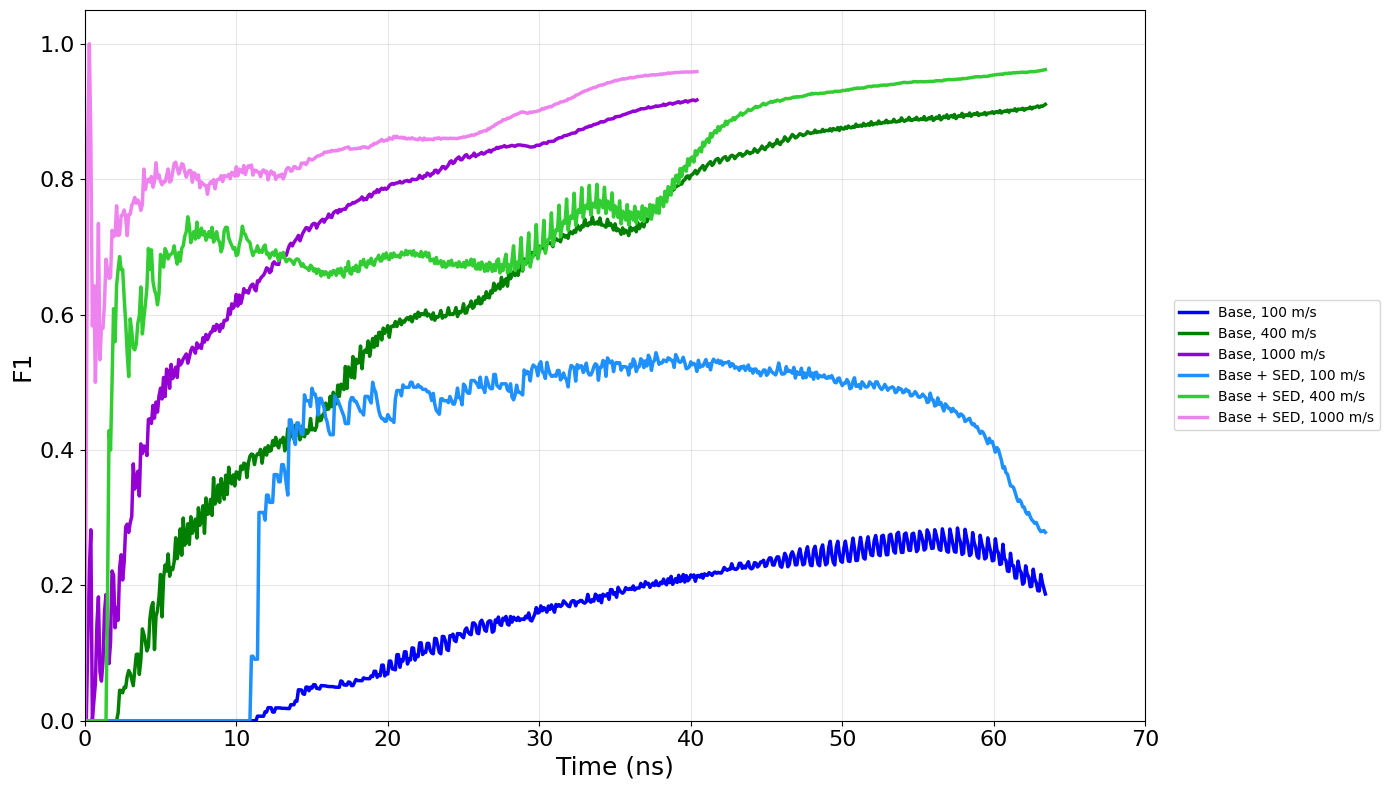

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/f1_full_simulation_comparison.png


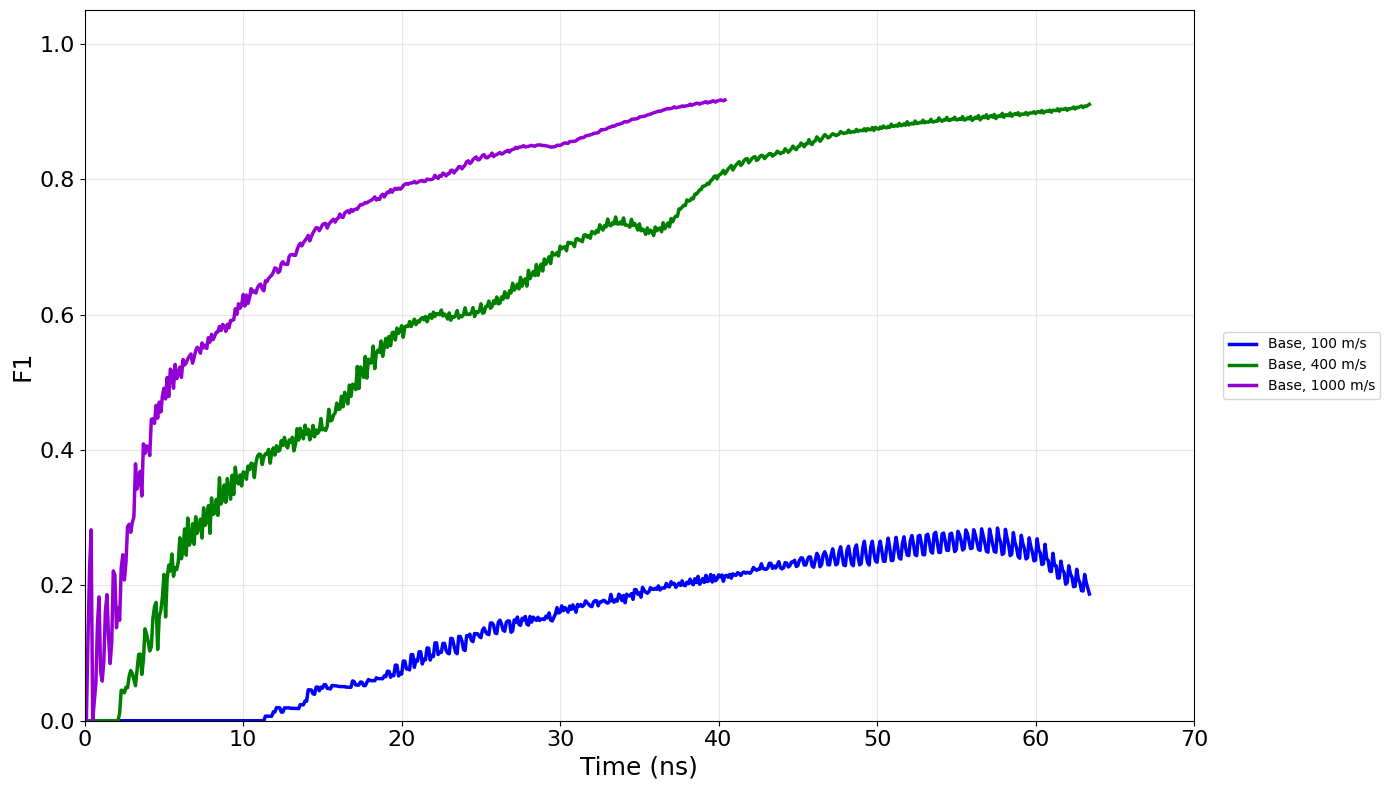

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/f1_full_simulation_base_only.png


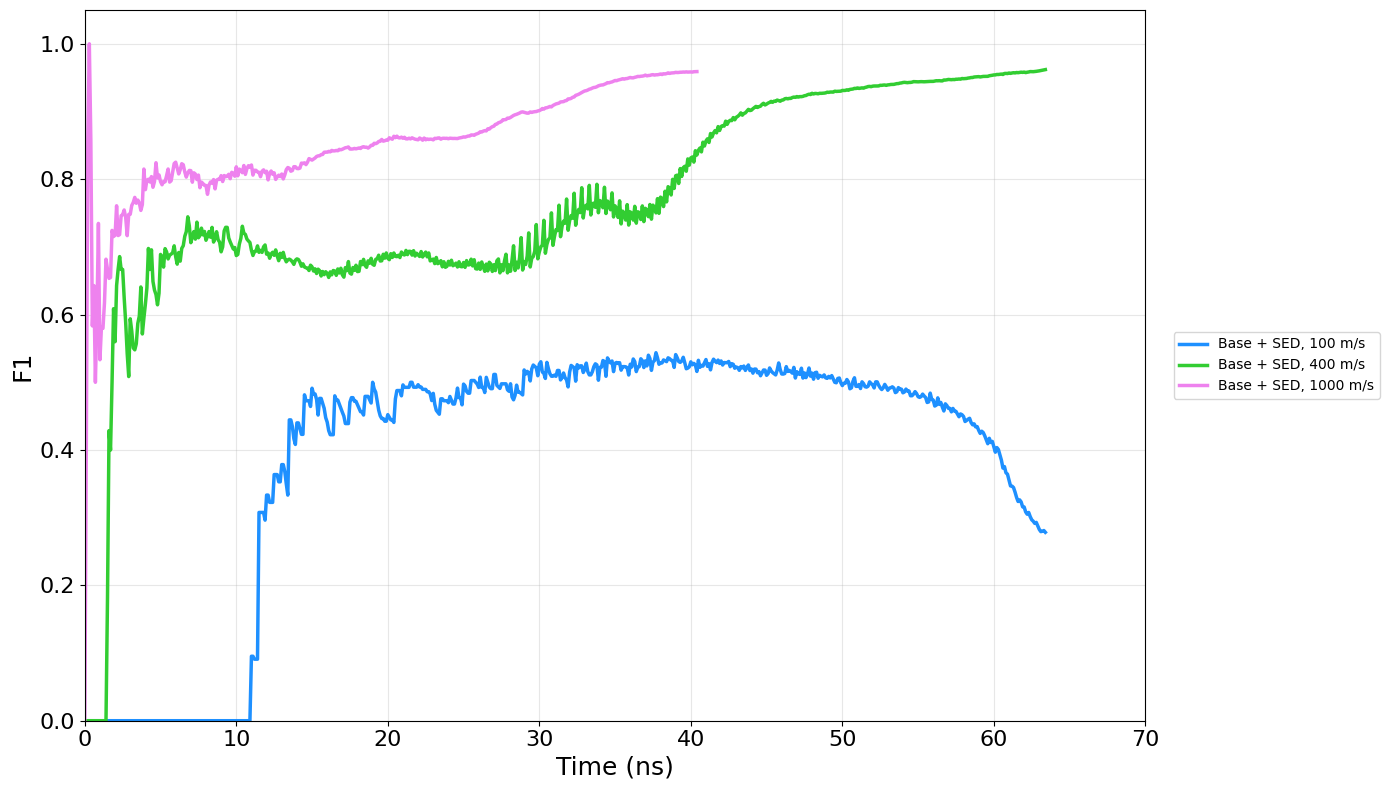

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/f1_full_simulation_base_plus_sed_only.png


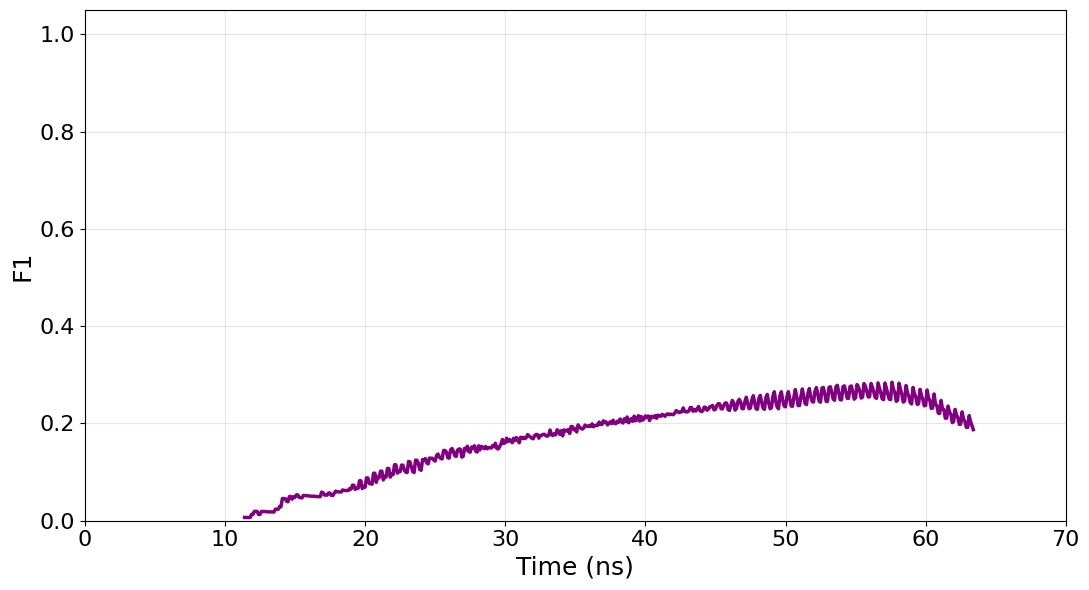

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_f1_plots/f1_over_time_base_100_m_s.png


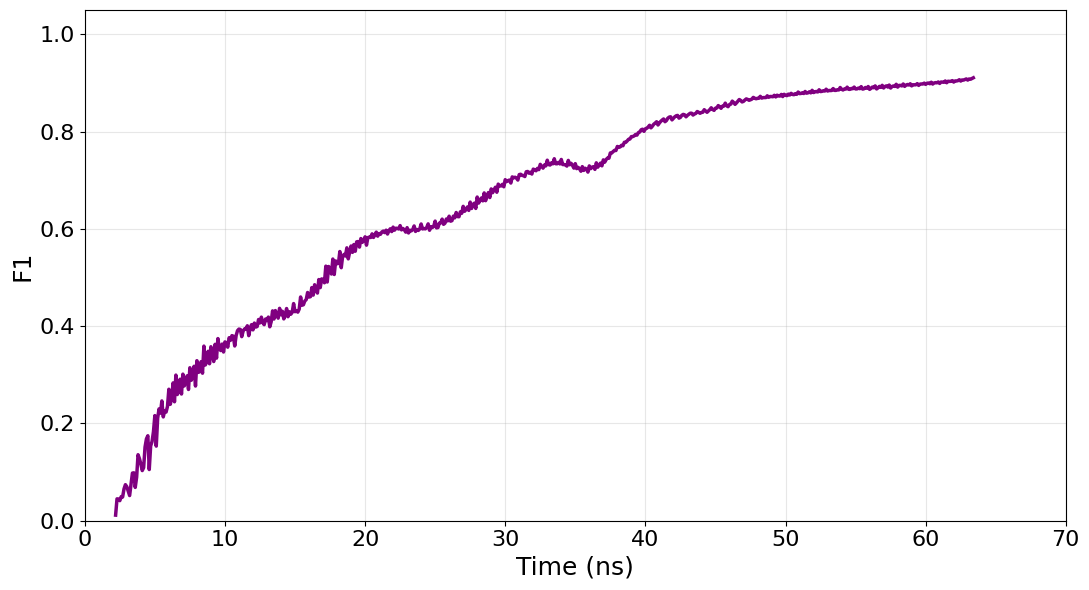

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_f1_plots/f1_over_time_base_400_m_s.png


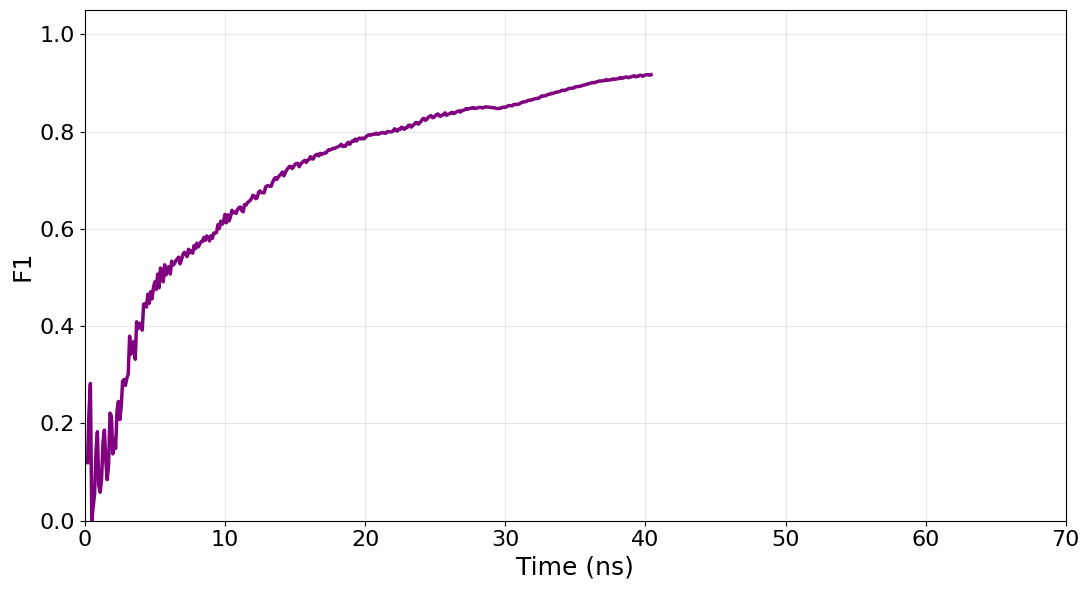

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_f1_plots/f1_over_time_base_1000_m_s.png


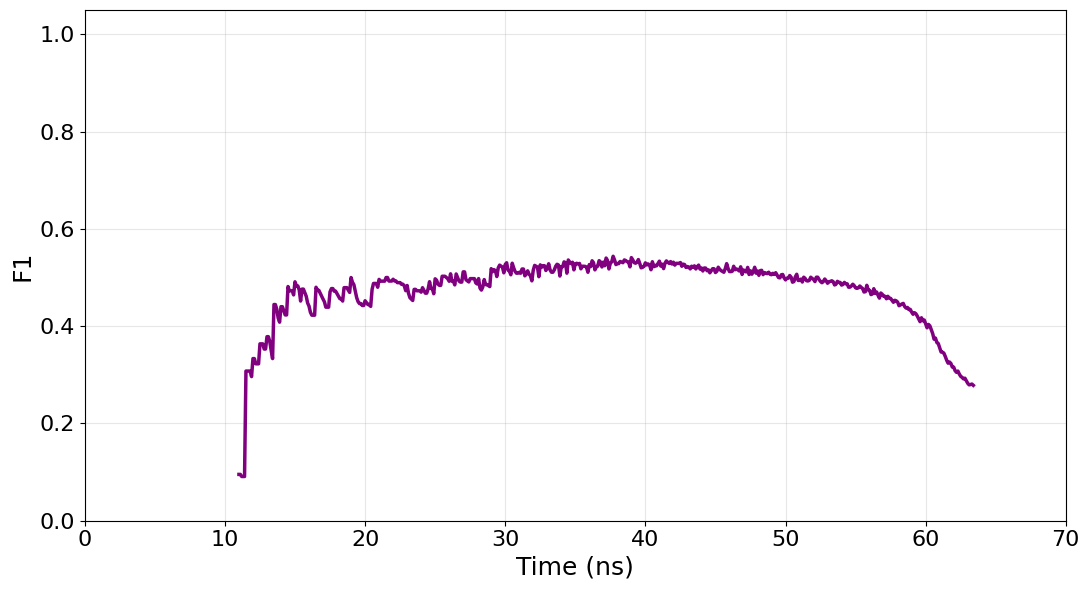

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_f1_plots/f1_over_time_base_plus_sed_100_m_s.png


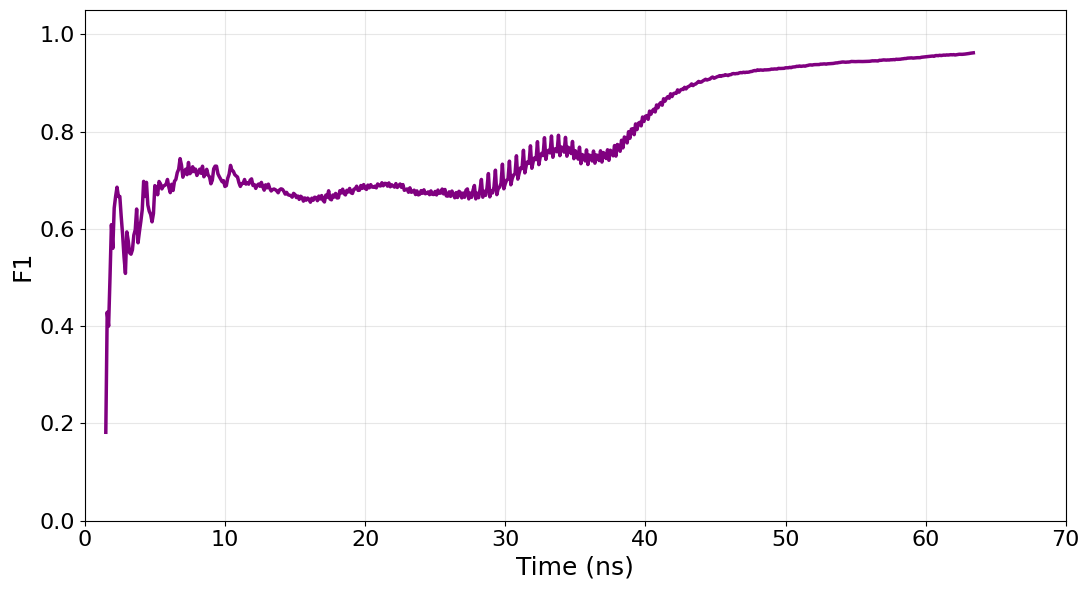

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_f1_plots/f1_over_time_base_plus_sed_400_m_s.png


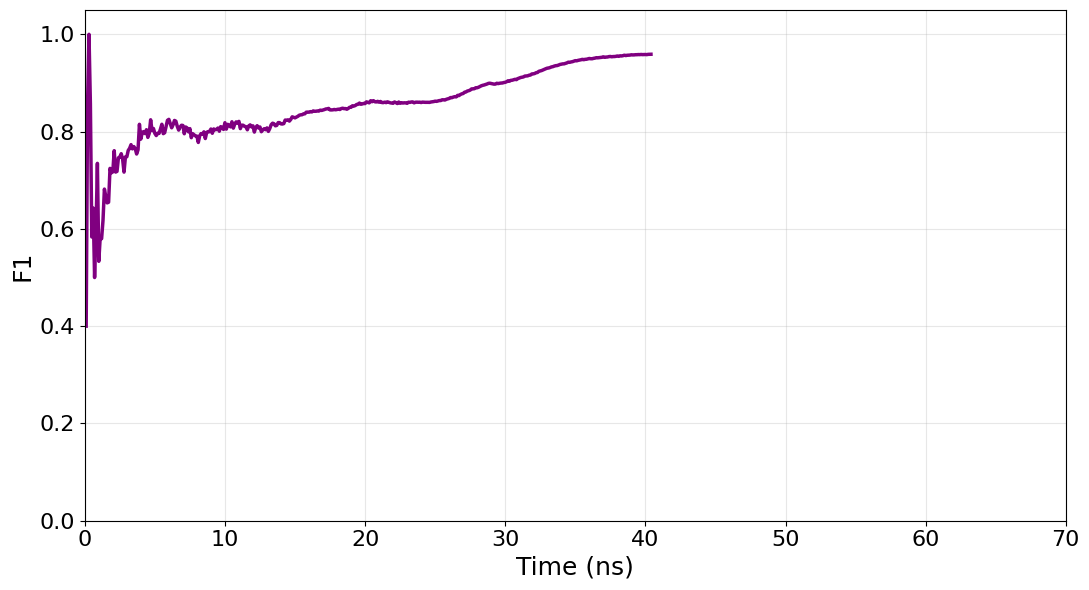

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_f1_plots/f1_over_time_base_plus_sed_1000_m_s.png


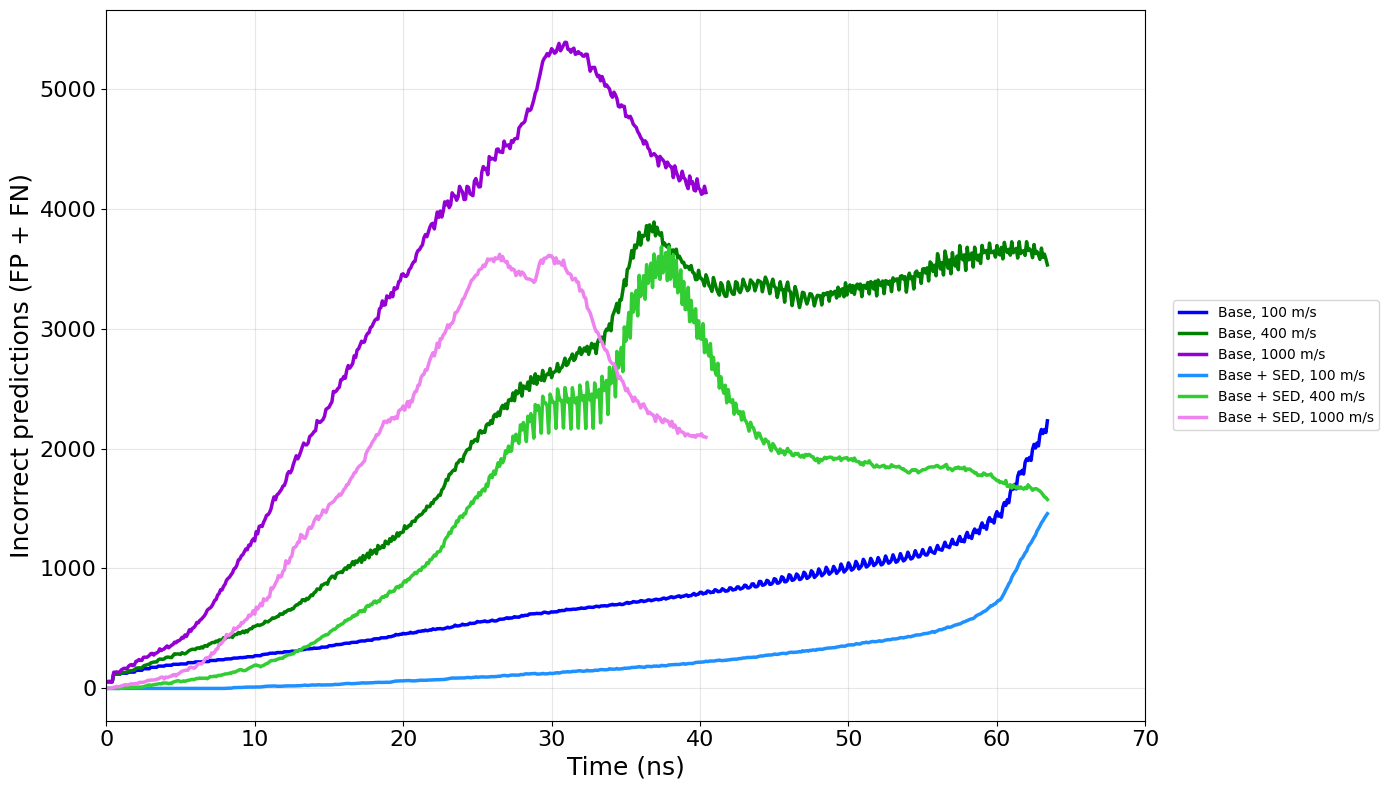

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_full_simulation_comparison.png


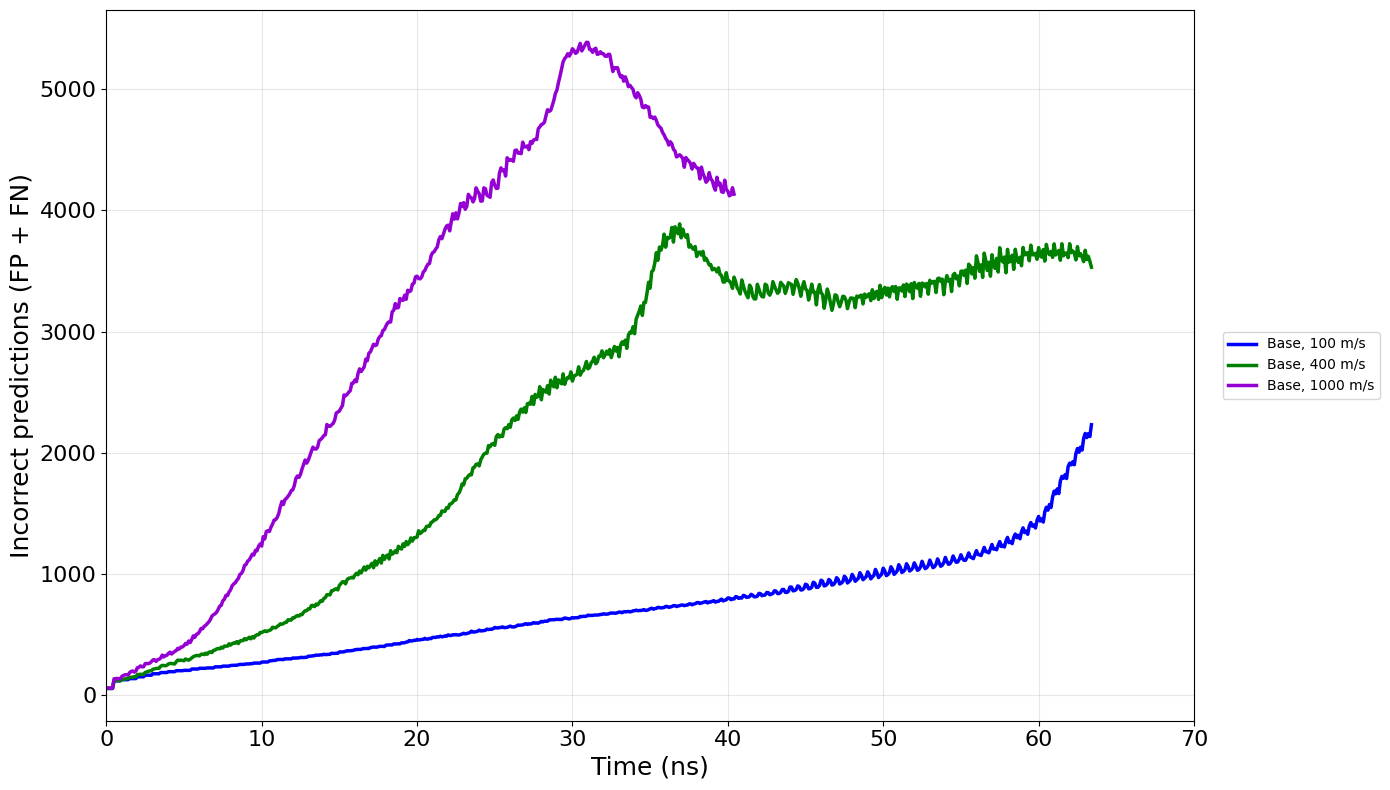

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_full_simulation_base_only.png


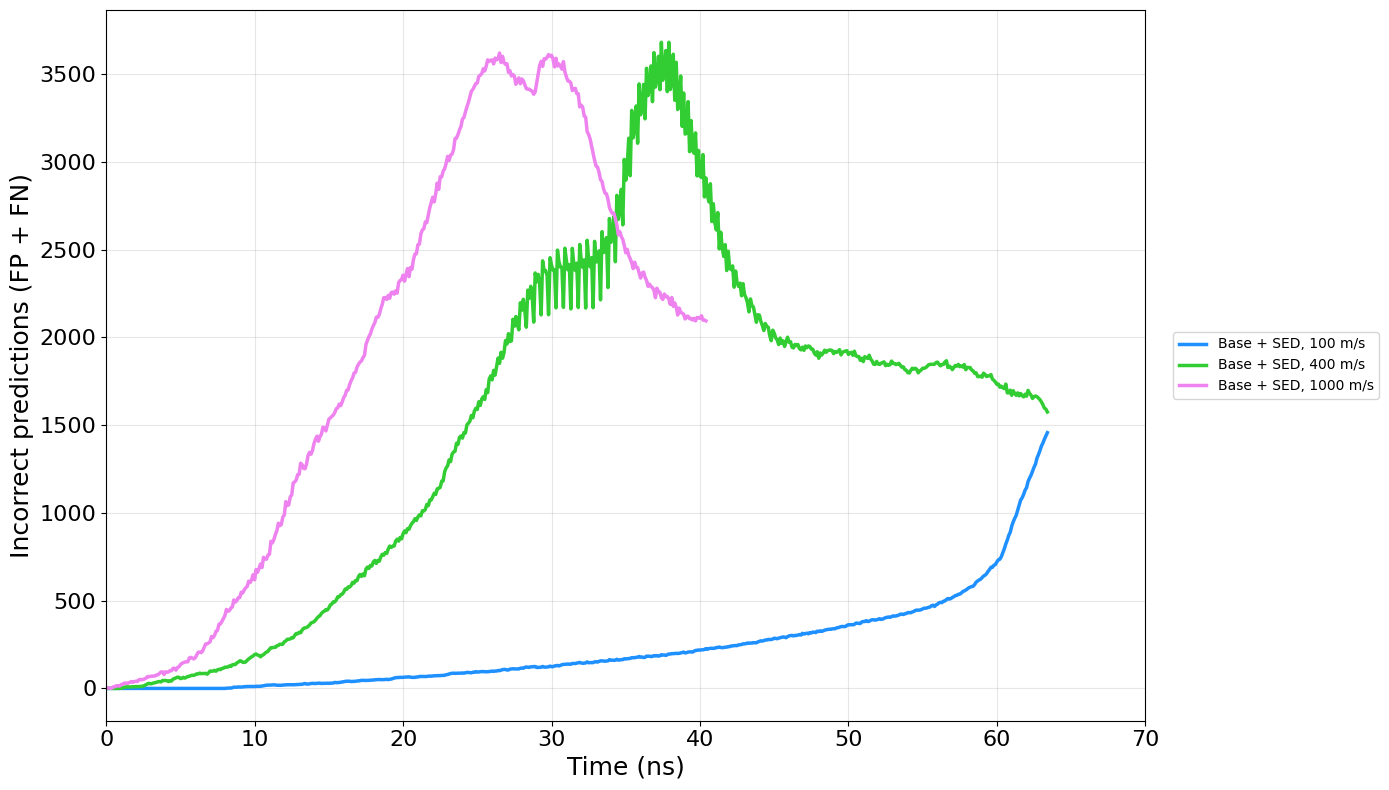

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_full_simulation_base_plus_sed_only.png


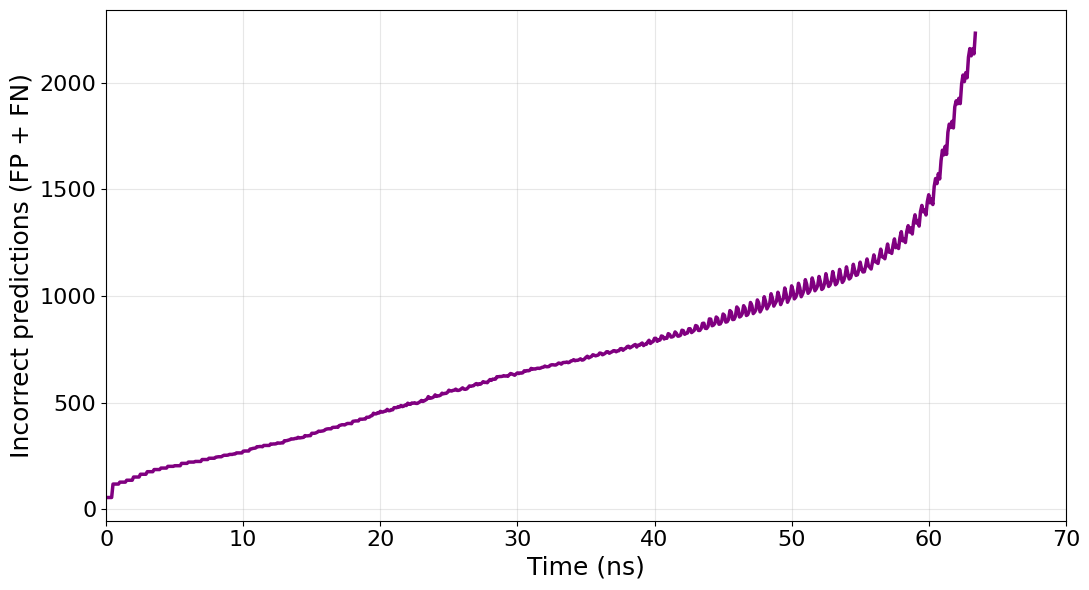

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_plots/incorrect_predictions_over_time_base_100_m_s.png


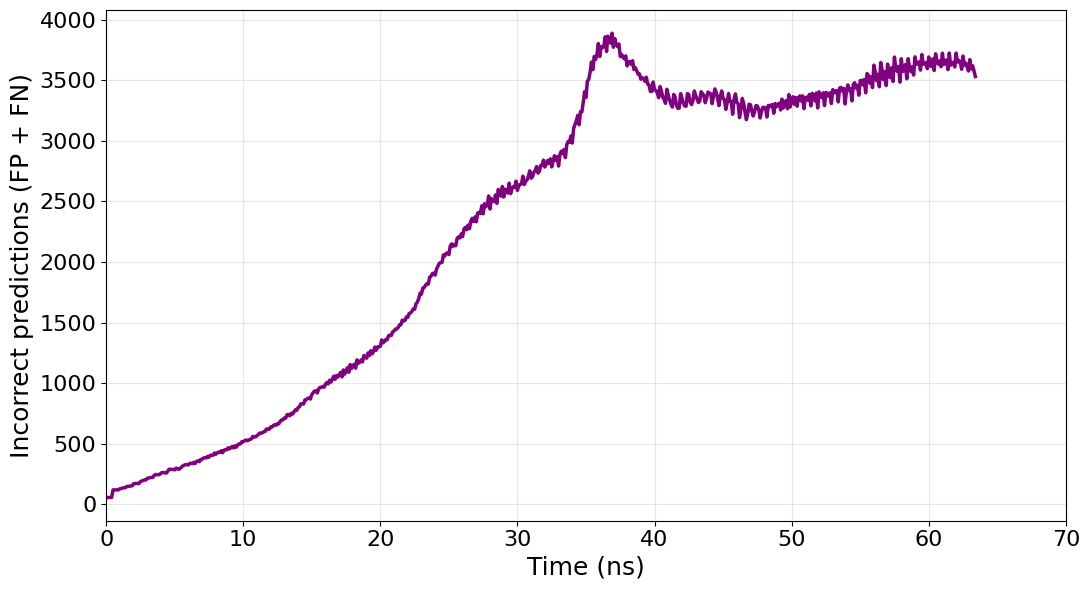

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_plots/incorrect_predictions_over_time_base_400_m_s.png


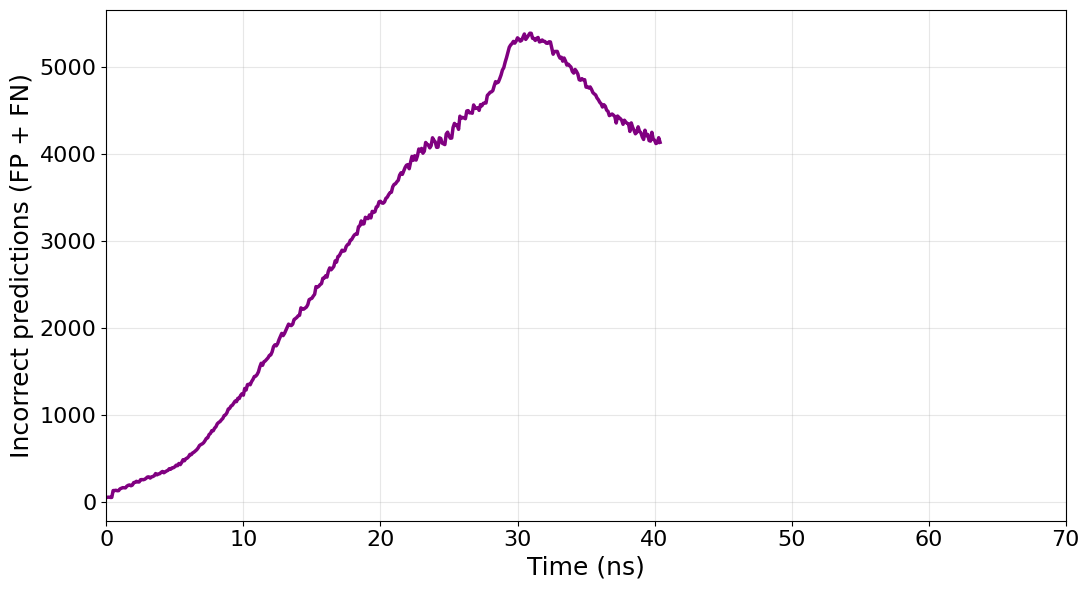

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_plots/incorrect_predictions_over_time_base_1000_m_s.png


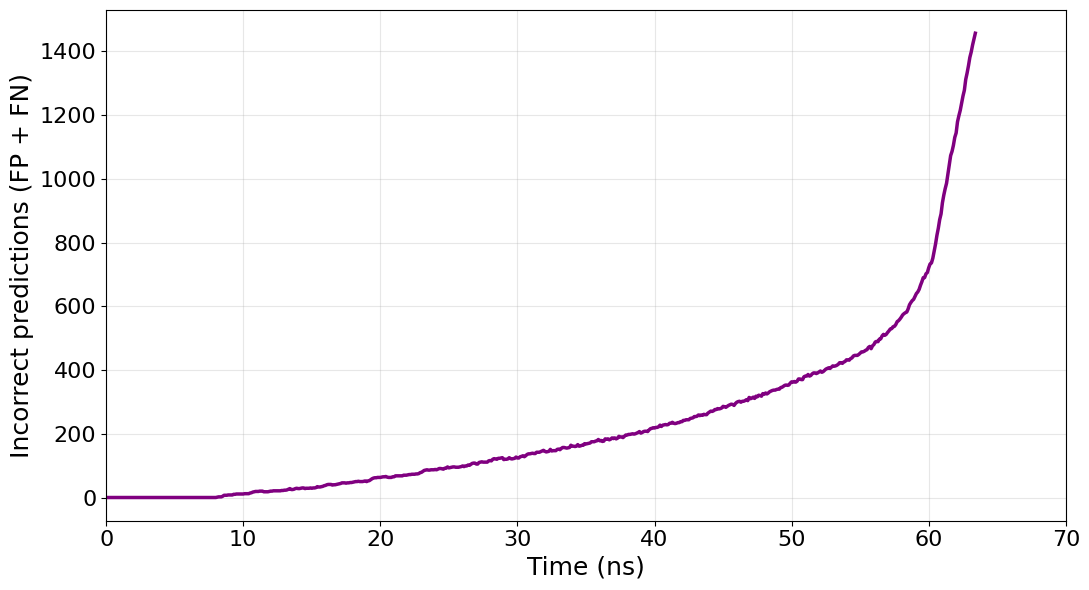

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_plots/incorrect_predictions_over_time_base_plus_sed_100_m_s.png


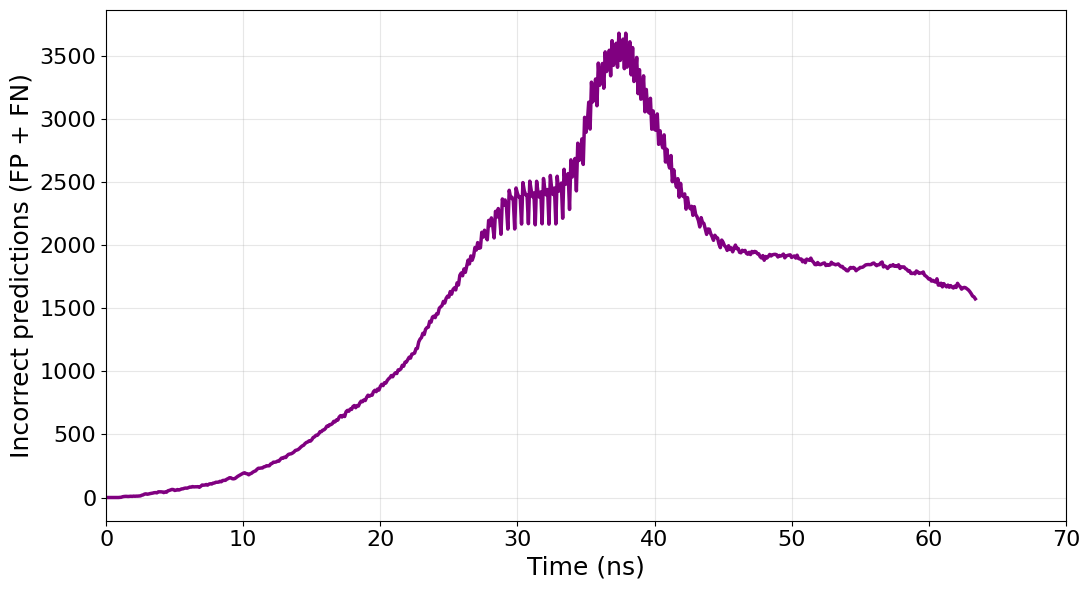

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_plots/incorrect_predictions_over_time_base_plus_sed_400_m_s.png


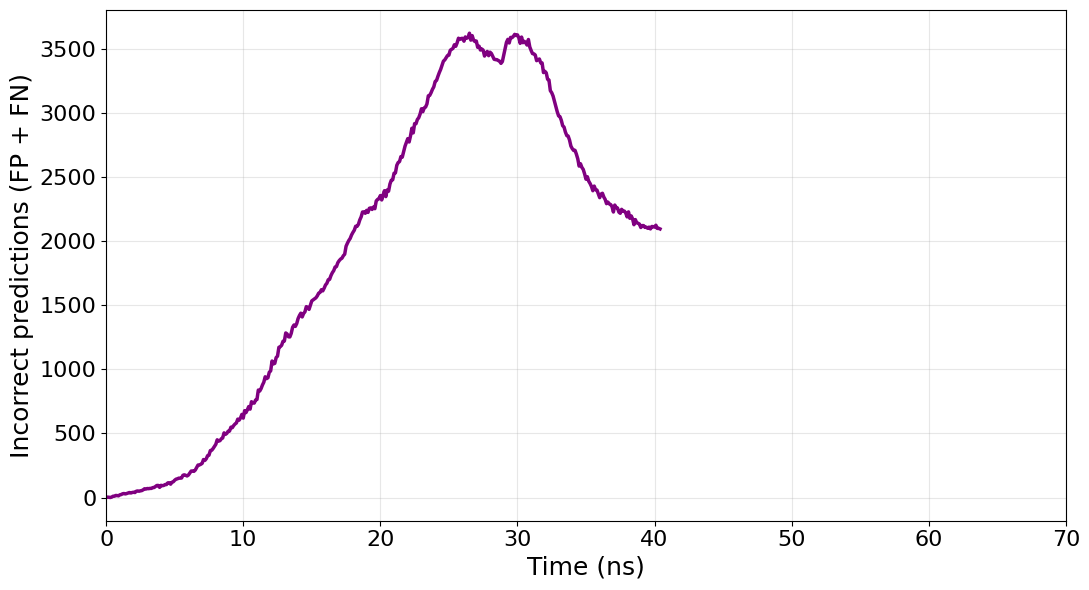

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_plots/incorrect_predictions_over_time_base_plus_sed_1000_m_s.png


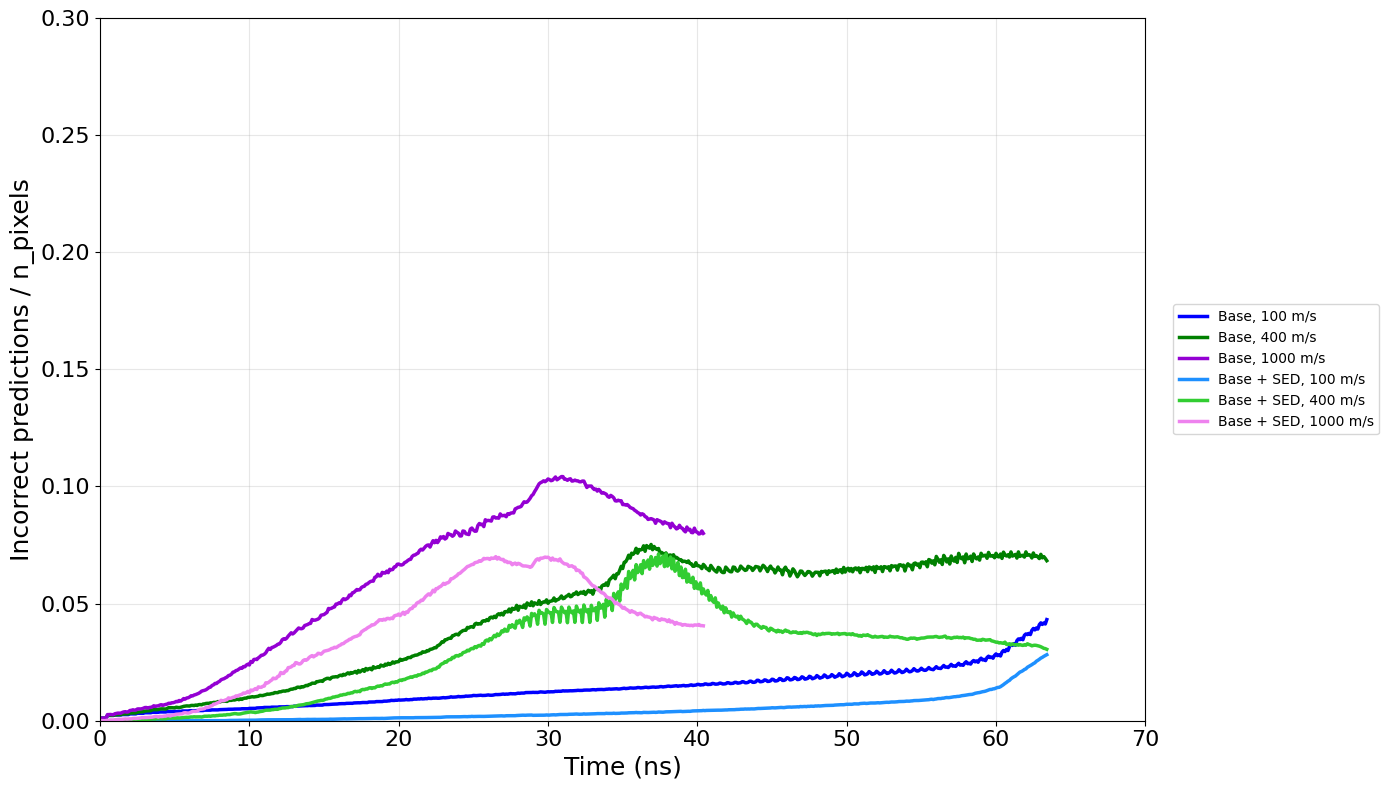

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_per_npixels_full_simulation_comparison.png


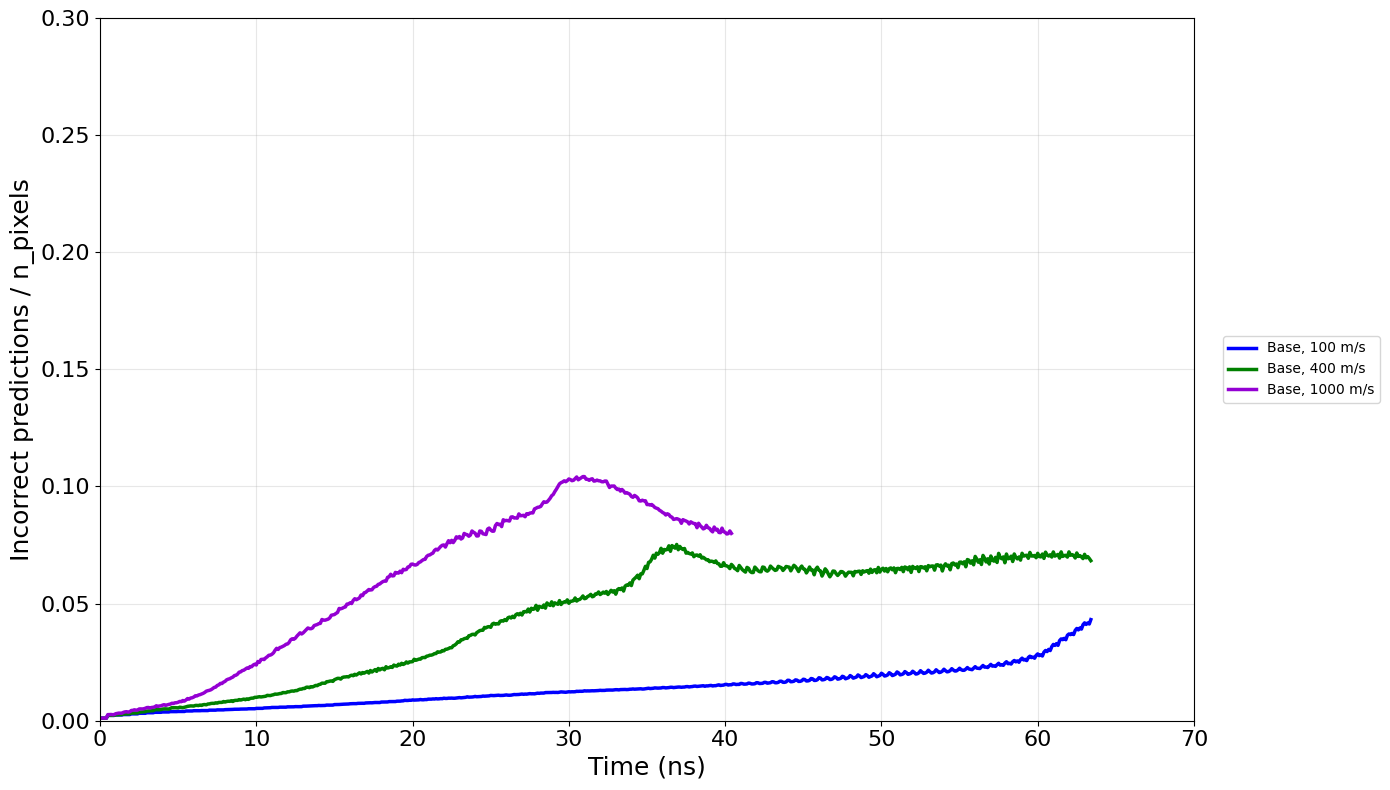

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_per_npixels_full_simulation_base_only.png


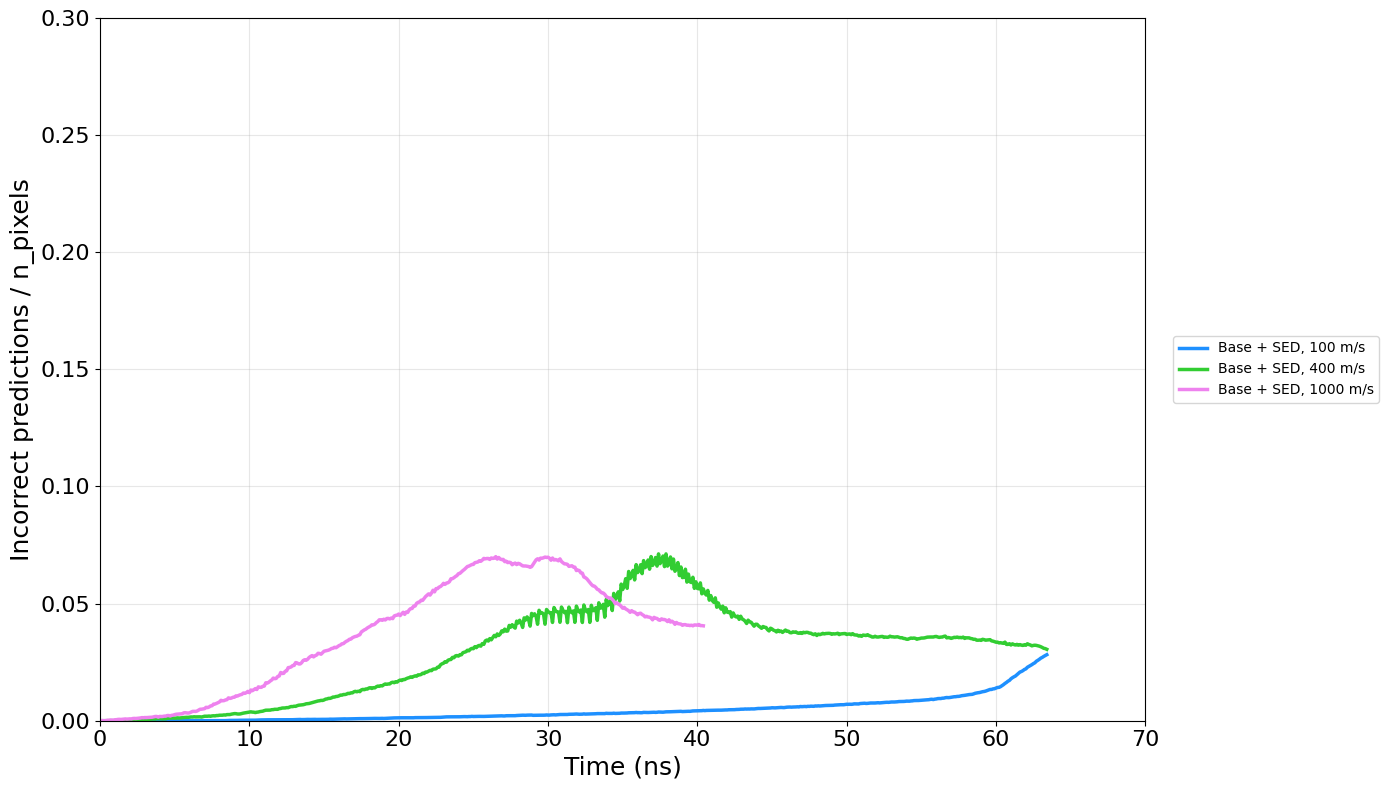

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_per_npixels_full_simulation_base_plus_sed_only.png


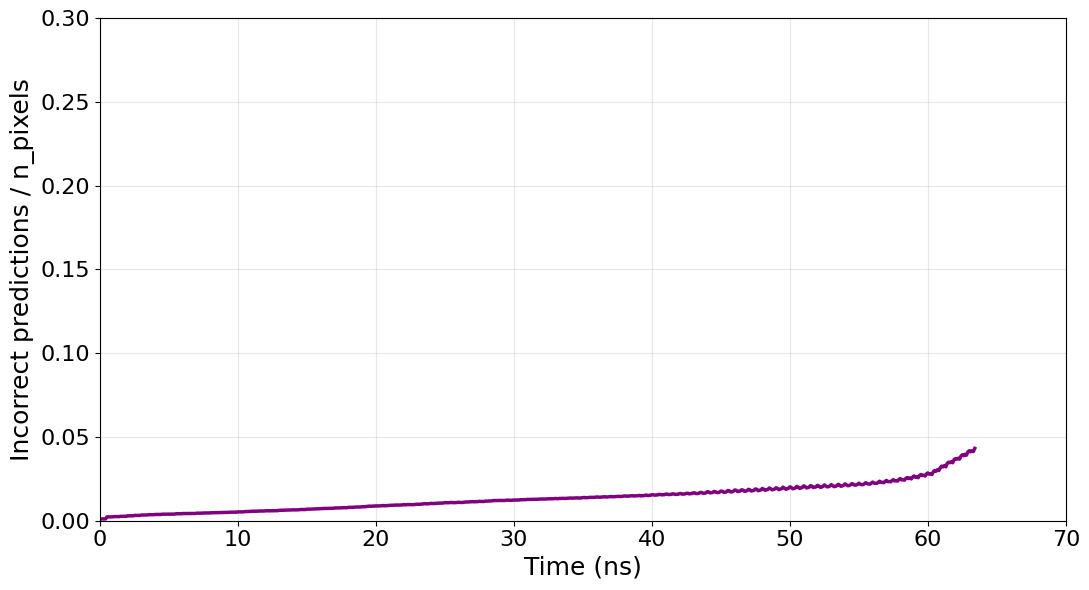

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_per_npixels_plots/incorrect_predictions_per_npixels_over_time_base_100_m_s.png


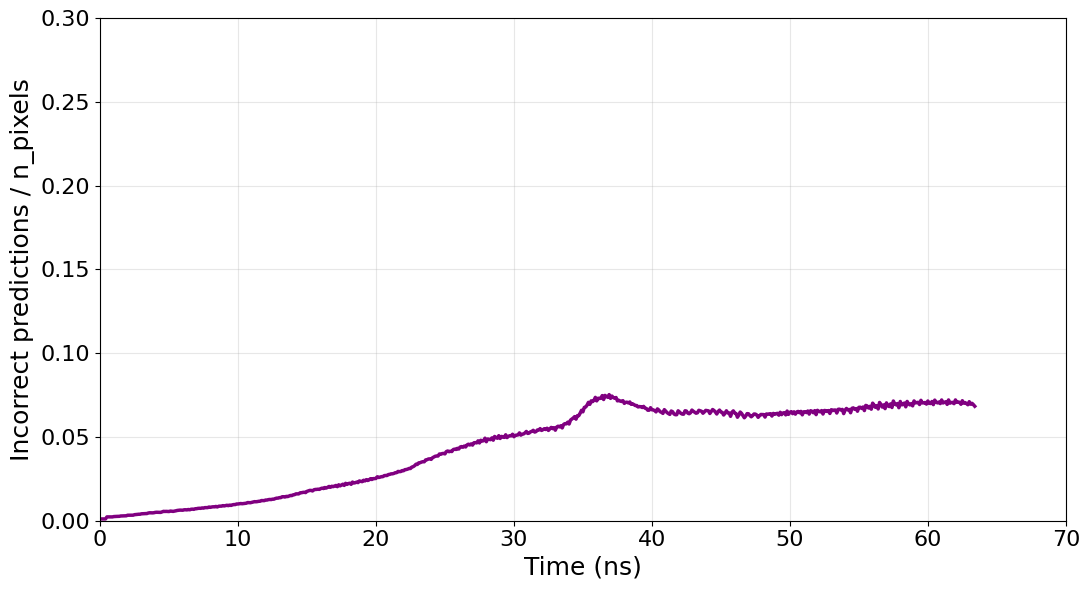

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_per_npixels_plots/incorrect_predictions_per_npixels_over_time_base_400_m_s.png


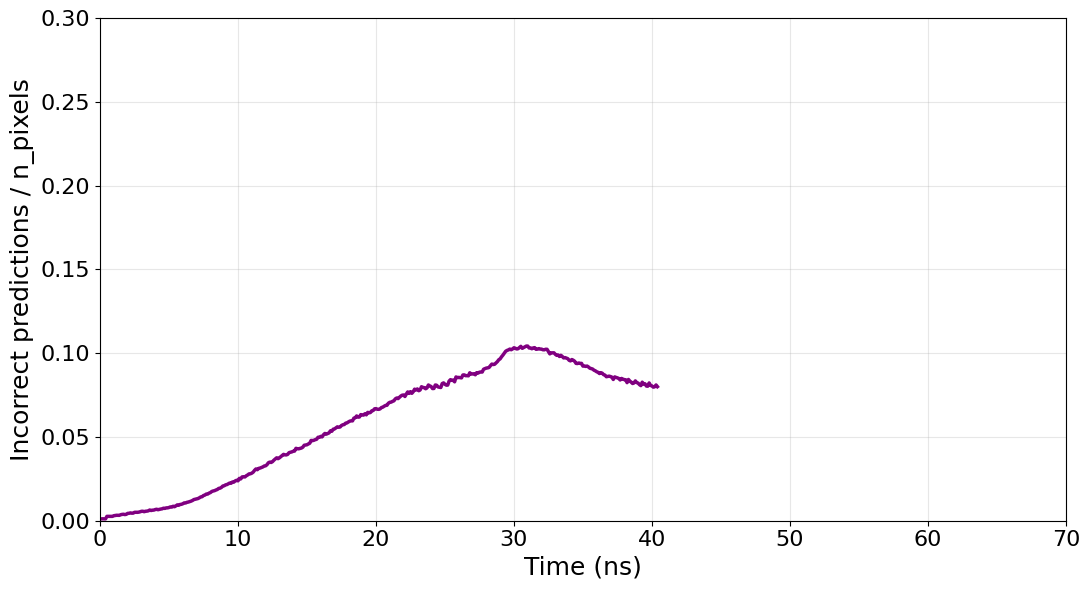

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_per_npixels_plots/incorrect_predictions_per_npixels_over_time_base_1000_m_s.png


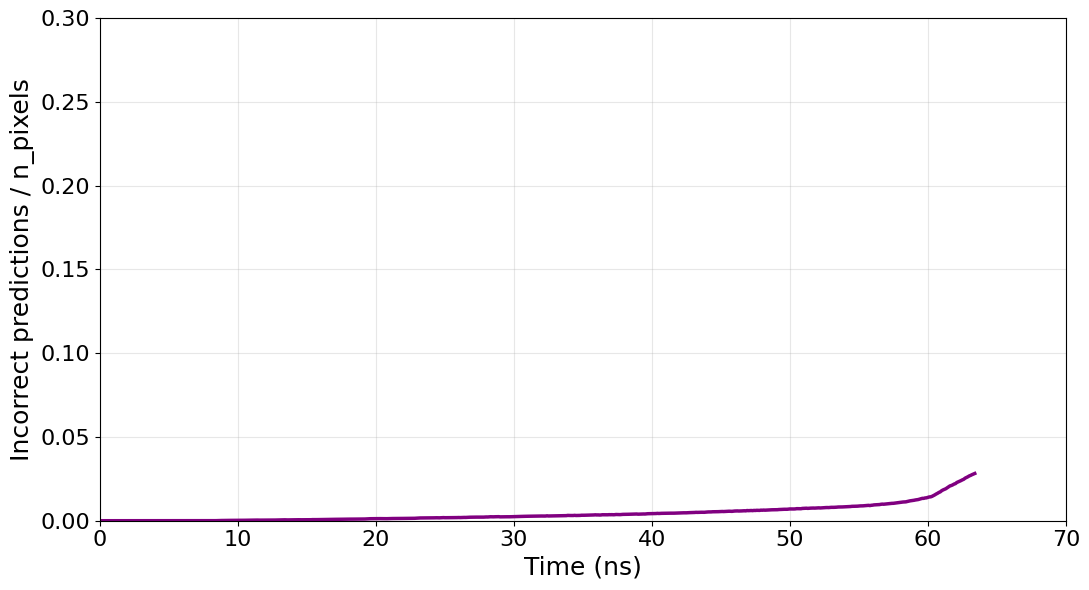

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_per_npixels_plots/incorrect_predictions_per_npixels_over_time_base_plus_sed_100_m_s.png


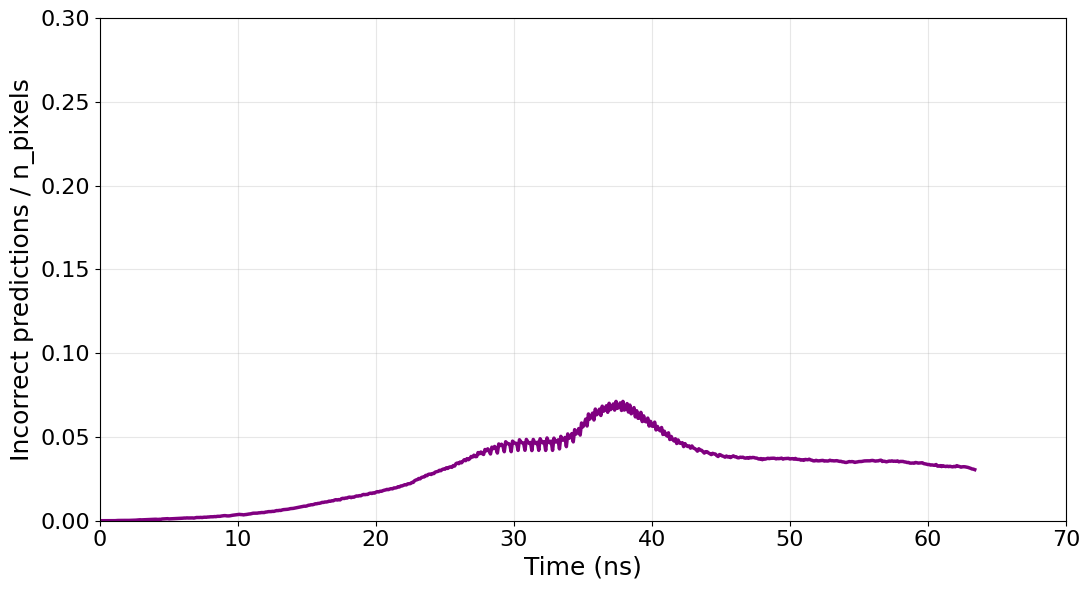

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_per_npixels_plots/incorrect_predictions_per_npixels_over_time_base_plus_sed_400_m_s.png


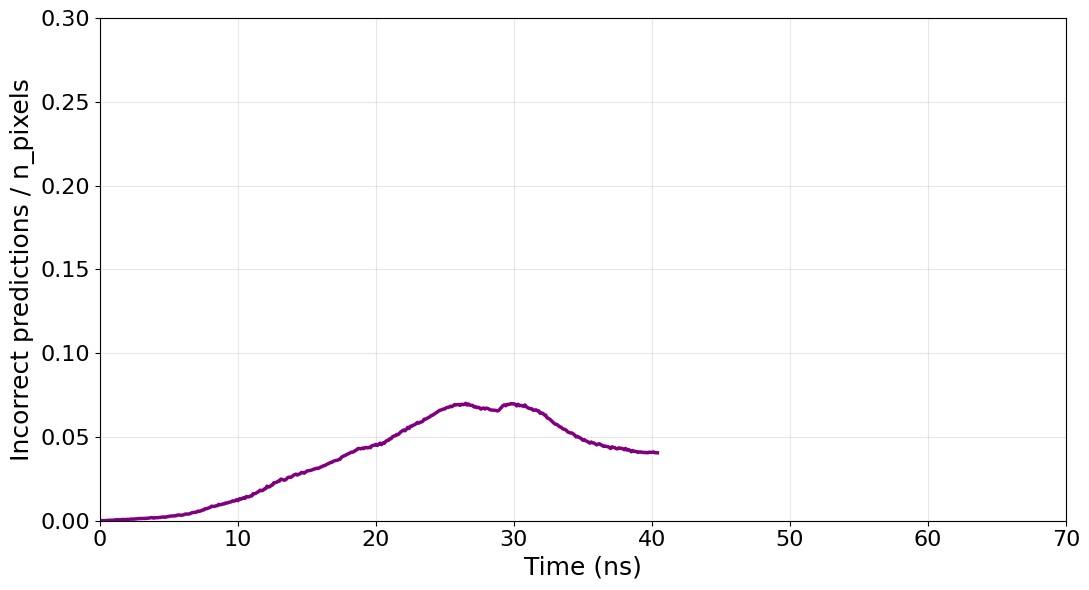

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_per_npixels_plots/incorrect_predictions_per_npixels_over_time_base_plus_sed_1000_m_s.png


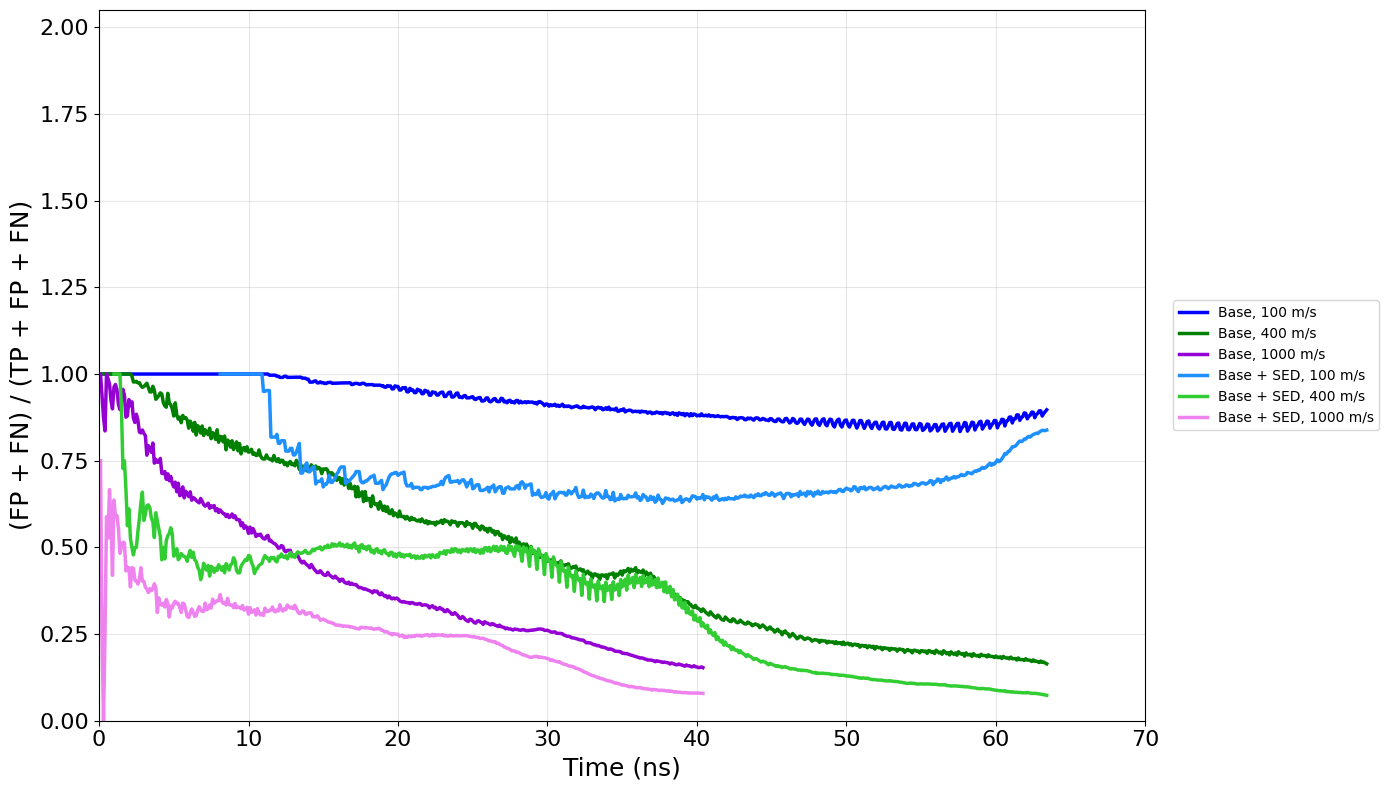

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_over_predunion_full_simulation_comparison.png


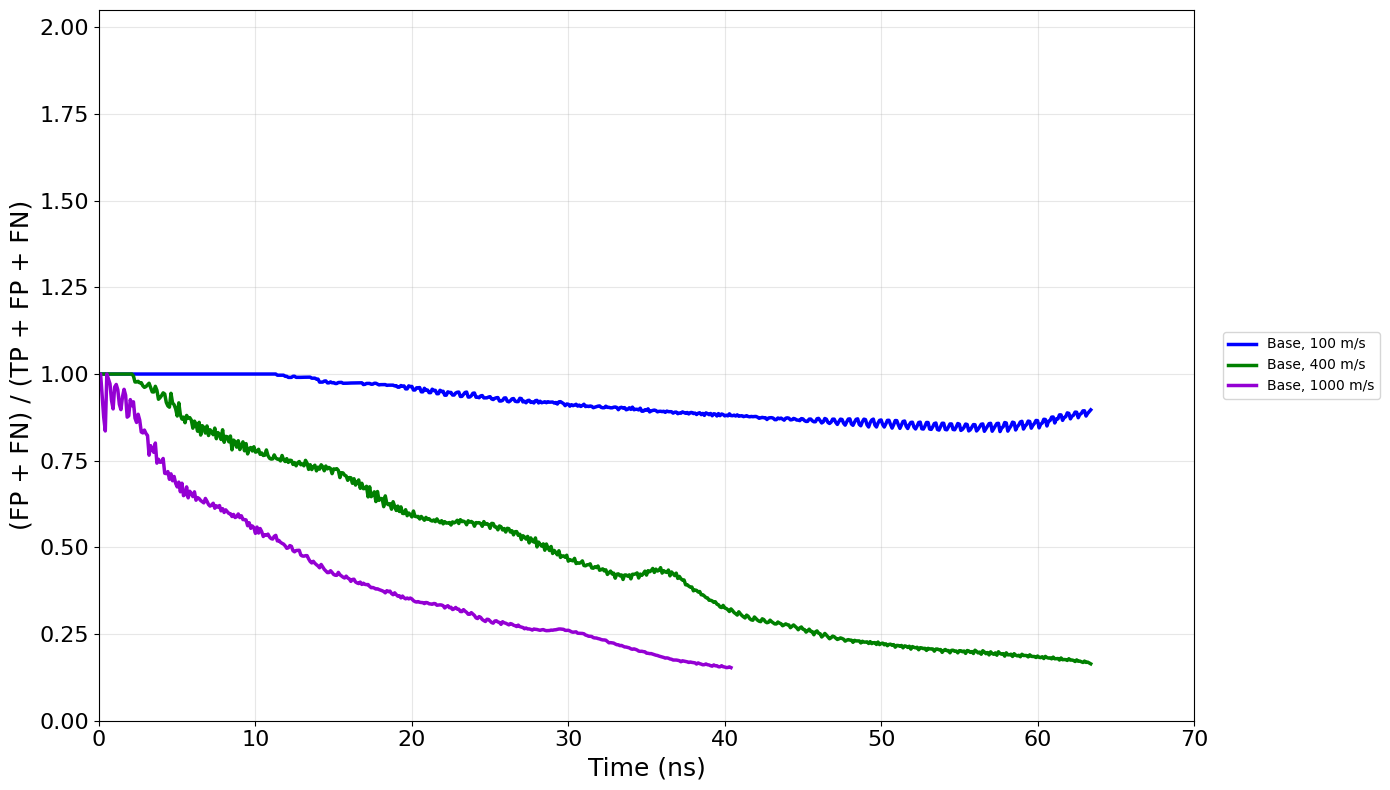

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_over_predunion_full_simulation_base_only.png


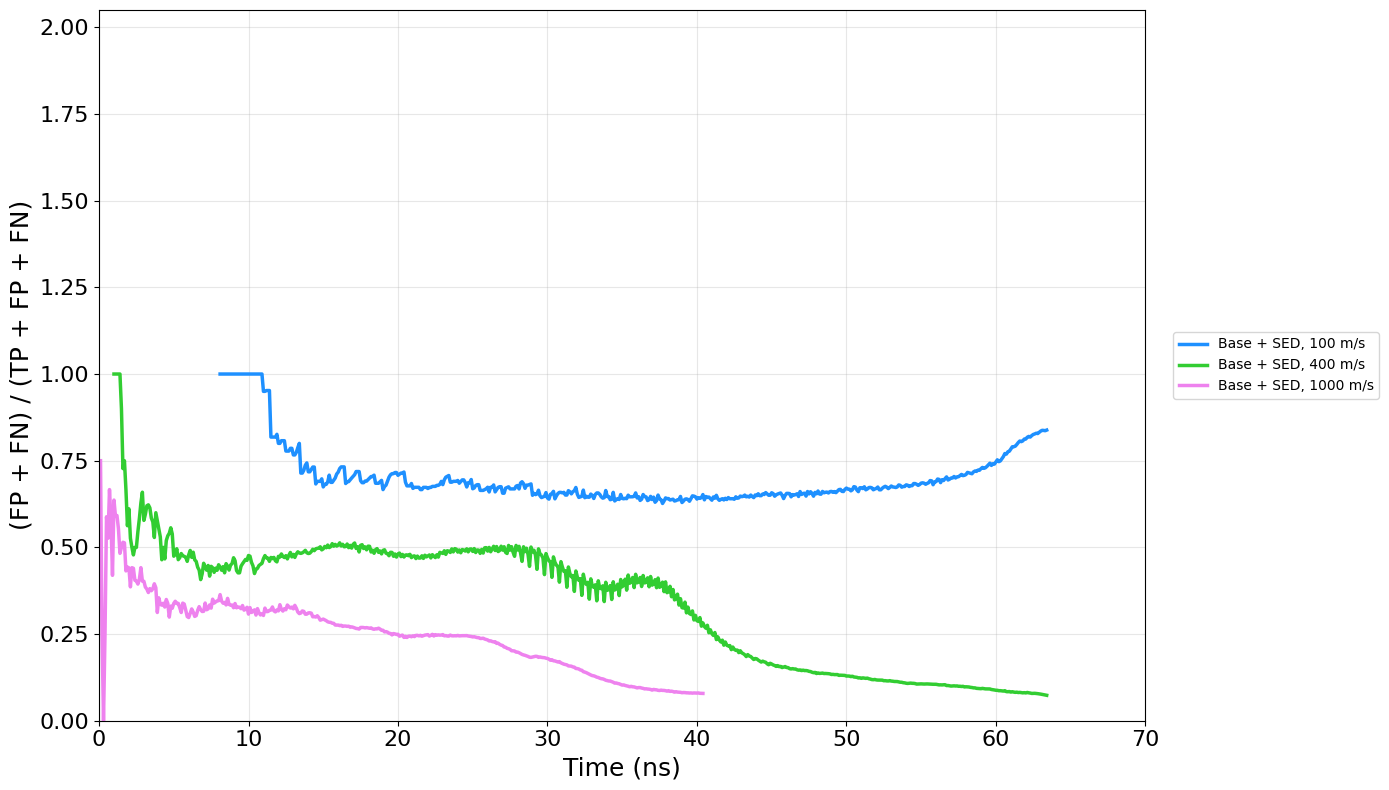

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/incorrect_predictions_over_predunion_full_simulation_base_plus_sed_only.png


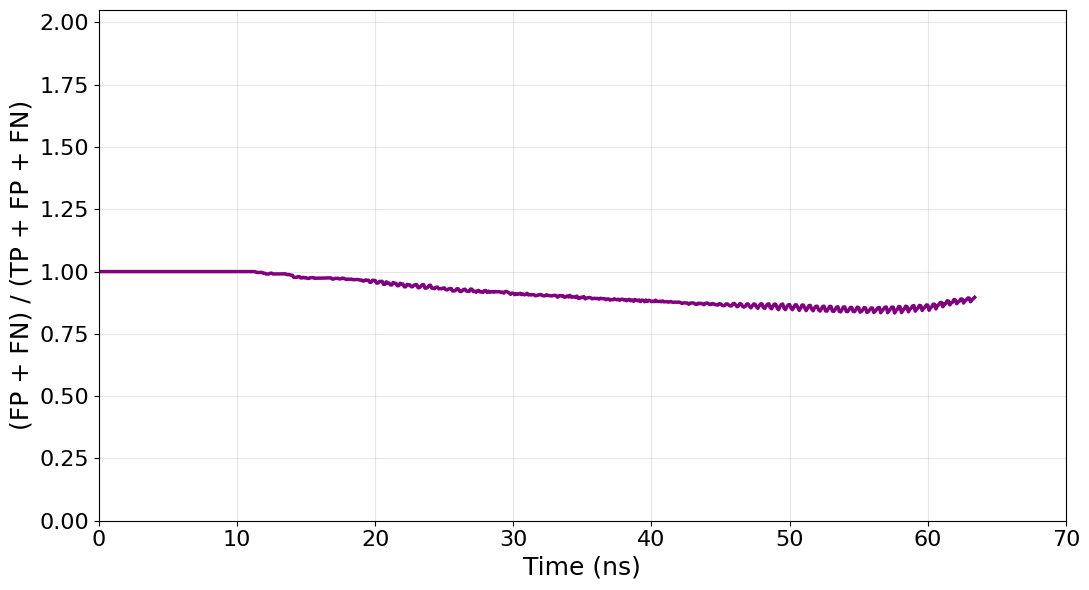

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_over_predunion_plots/incorrect_predictions_over_predunion_over_time_base_100_m_s.png


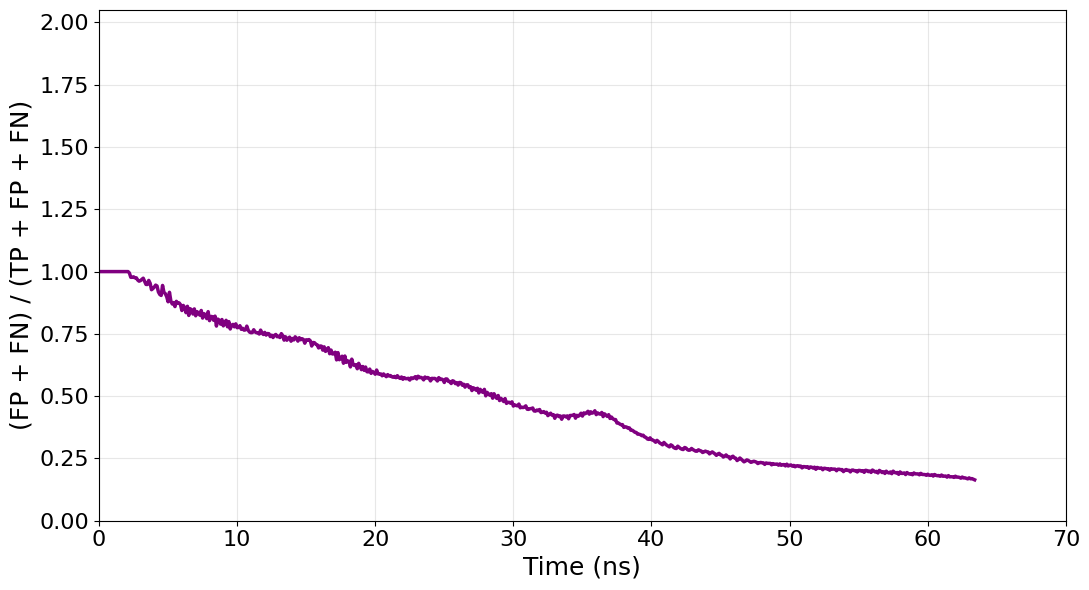

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_over_predunion_plots/incorrect_predictions_over_predunion_over_time_base_400_m_s.png


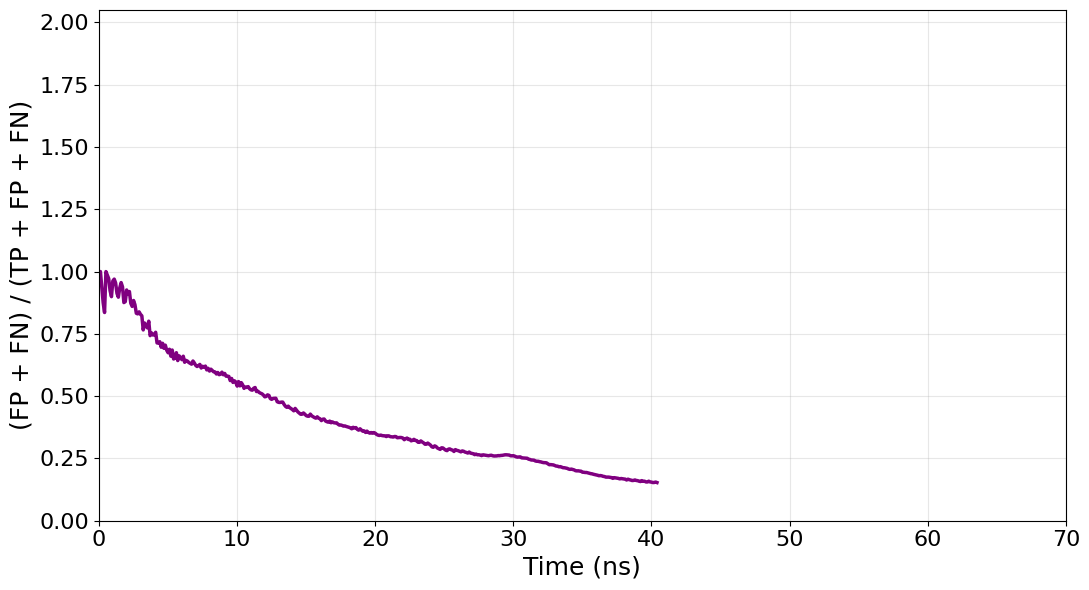

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_over_predunion_plots/incorrect_predictions_over_predunion_over_time_base_1000_m_s.png


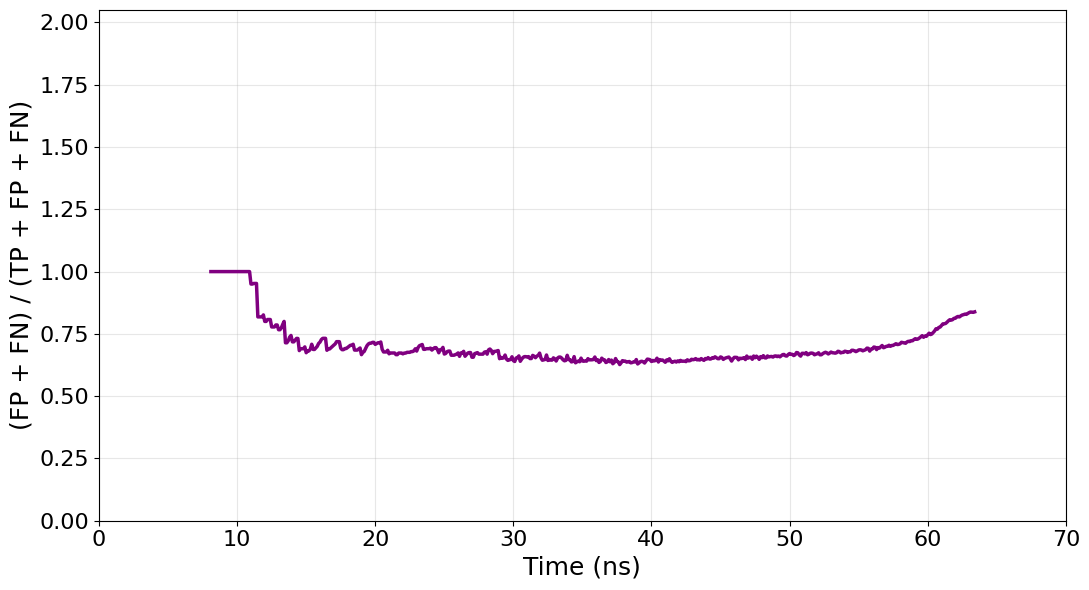

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_over_predunion_plots/incorrect_predictions_over_predunion_over_time_base_plus_sed_100_m_s.png


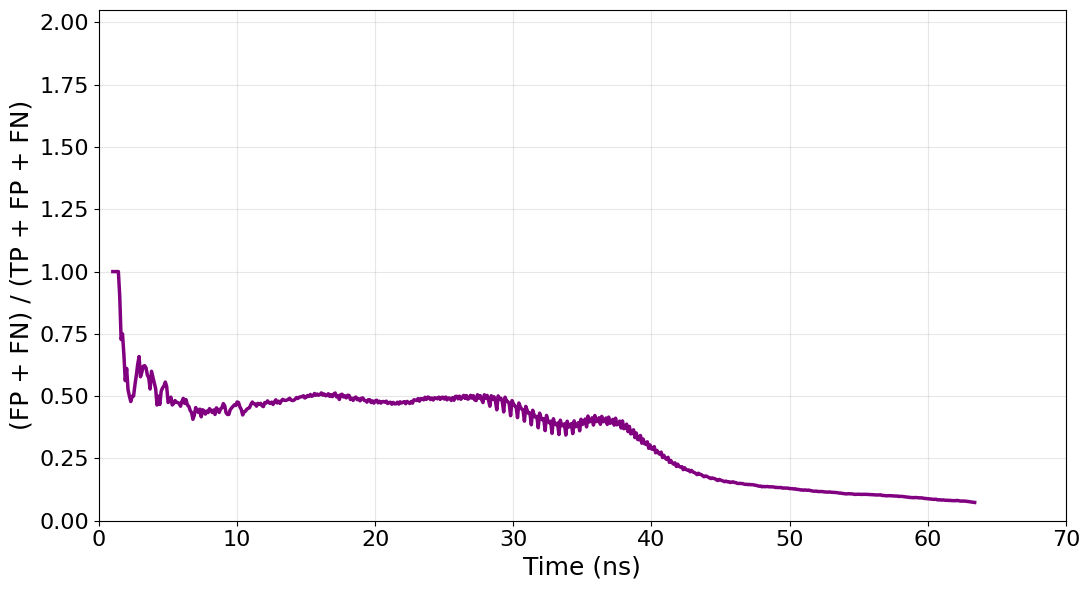

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_over_predunion_plots/incorrect_predictions_over_predunion_over_time_base_plus_sed_400_m_s.png


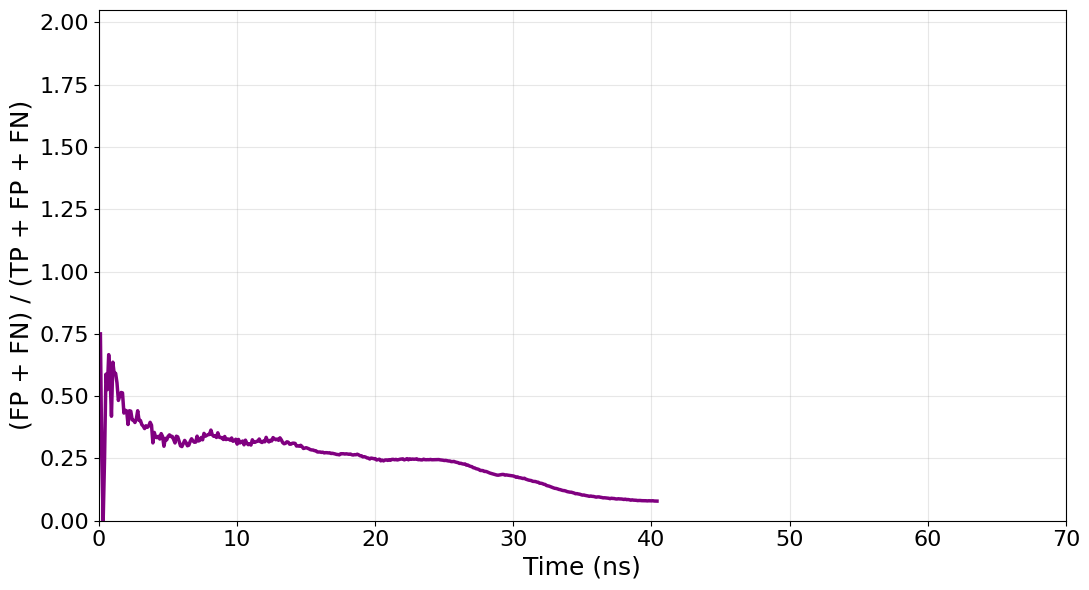

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_EMBR_3_20/FP_over_time/individual_incorrect_prediction_over_predunion_plots/incorrect_predictions_over_predunion_over_time_base_plus_sed_1000_m_s.png


In [27]:
info = pcfs.plot_f1_full_simulation_comparison(
    csv_map=csv_map,
    out_dir=out_dir,
    show=True,
    linewidth=2.5,
    colors_all=["blue", "green", "darkviolet", "dodgerblue", "limegreen", "violet"],
    colors_base=["blue", "green", "darkviolet"],
    colors_sed=["dodgerblue", "limegreen", "violet"],
    individual_color="purple",
    time_scale=1
)

### F1 across Base and Base + SED

In [396]:
out_dir = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR"



In [425]:
csv_map = {
    "Base": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V100/per_frame_metrics.csv",
        "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V200/per_frame_metrics.csv",
        "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V400/per_frame_metrics.csv",#"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forBase/testBase_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V1000/per_frame_metrics.csv",
    },
    "Base + SED": {
        "100 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V100/per_frame_metrics.csv",
        "200 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V200/per_frame_metrics.csv",
    "400 m/s":"/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V400/per_frame_metrics.csv",
     #   "400 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/TEST/forSED/test70epoch_test_MS206_V400/per_frame_metrics.csv",
        "1000 m/s": "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_SED/test_MS206_V1000/per_frame_metrics.csv",
    },
}


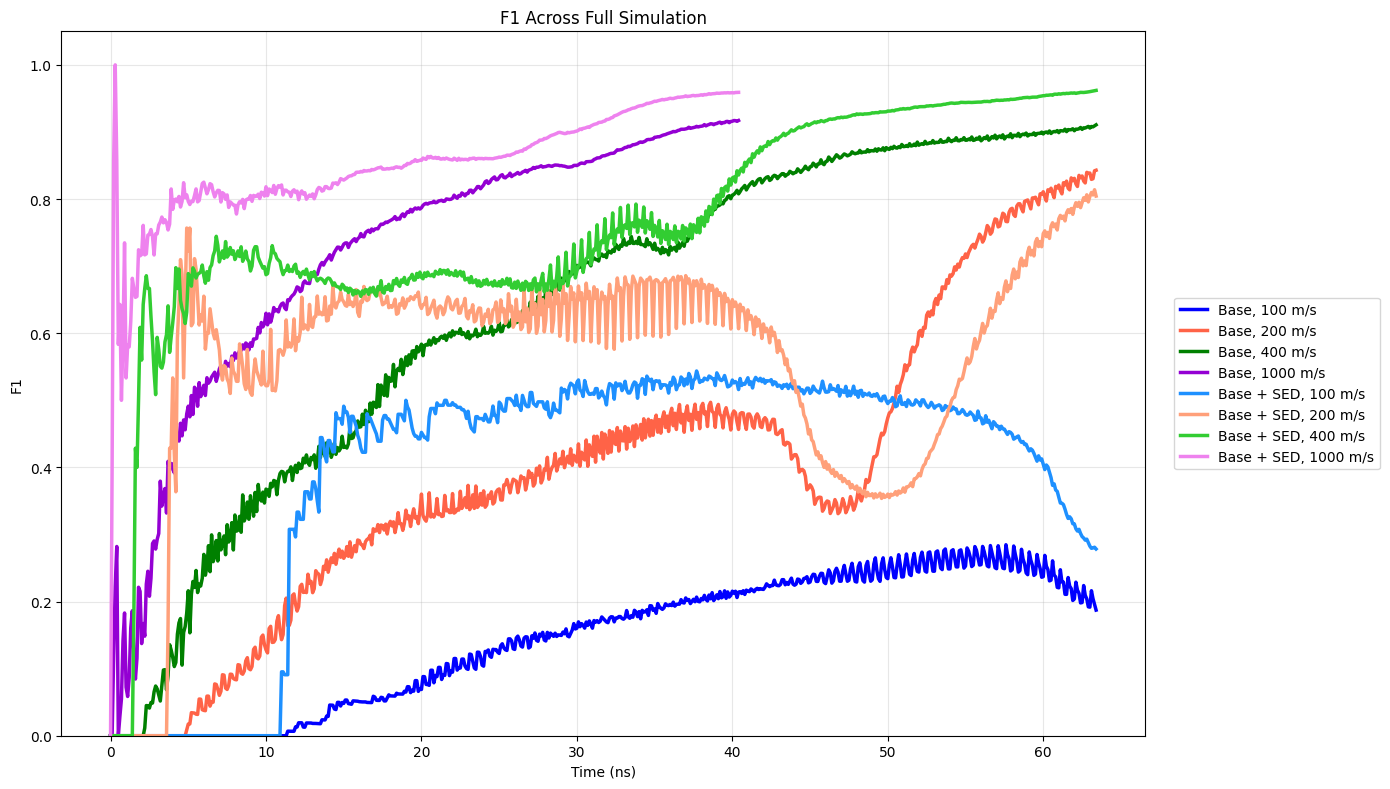

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/f1_full_simulation_comparison.png


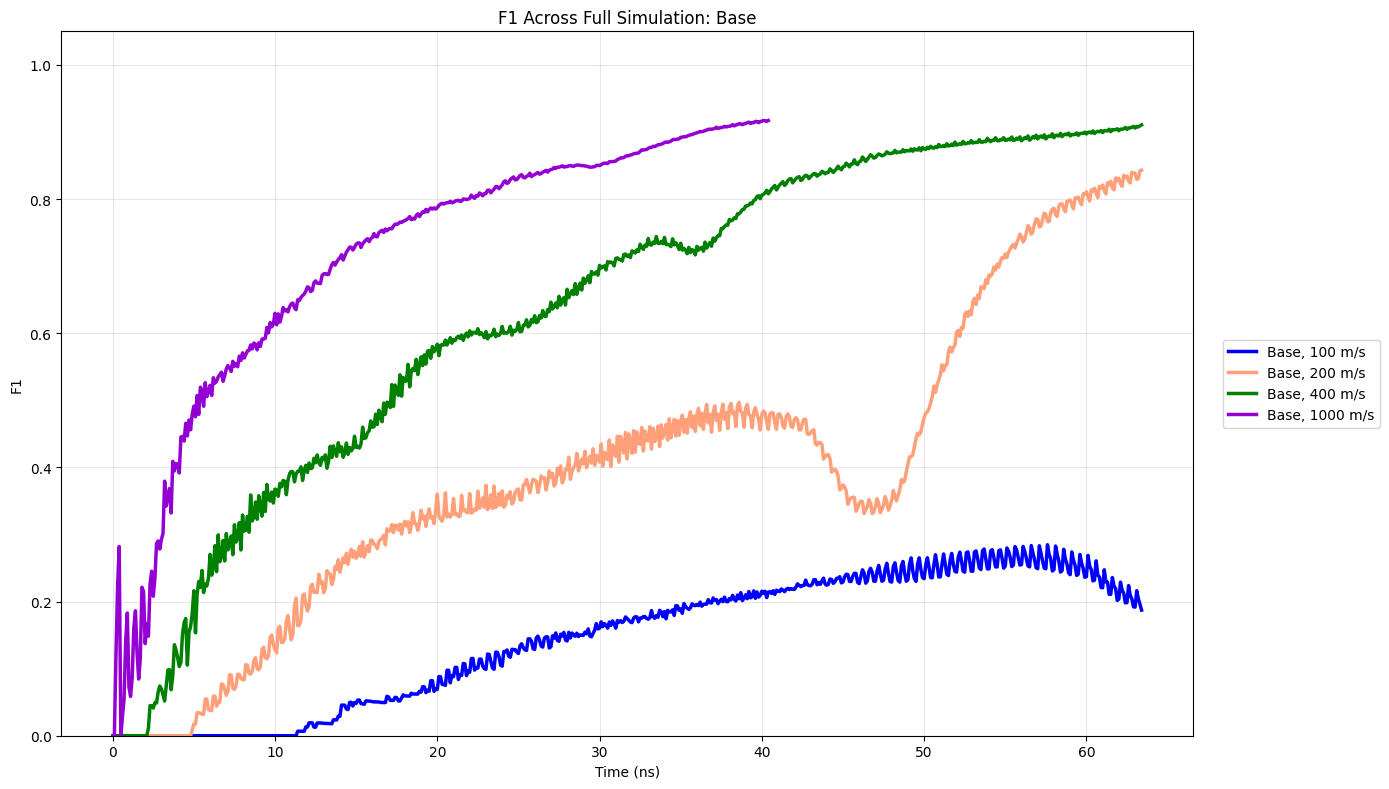

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/f1_full_simulation_base_only.png


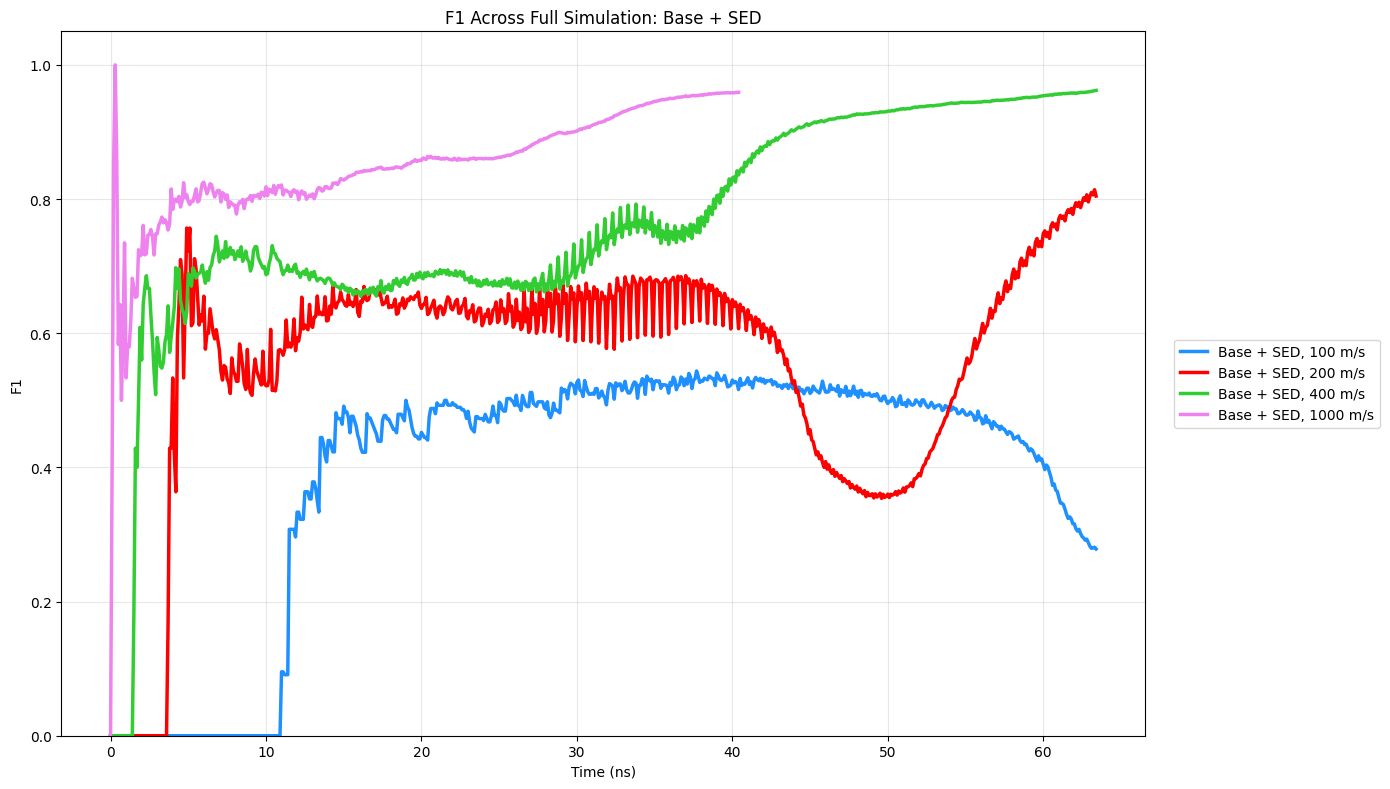

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/f1_full_simulation_base_plus_sed_only.png


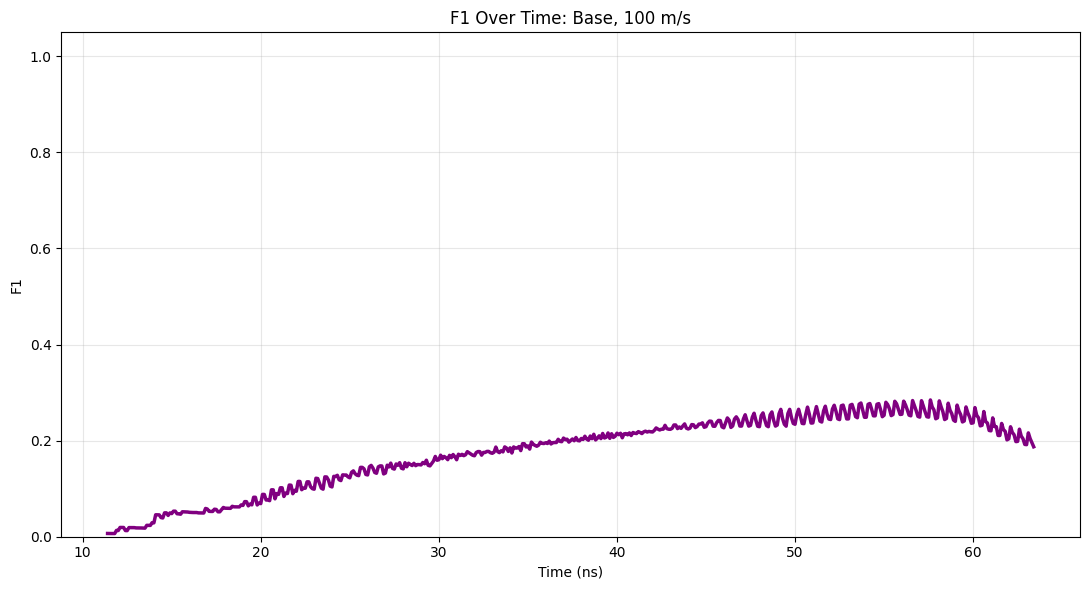

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/individual_f1_plots/f1_over_time_base_100_m_s.png


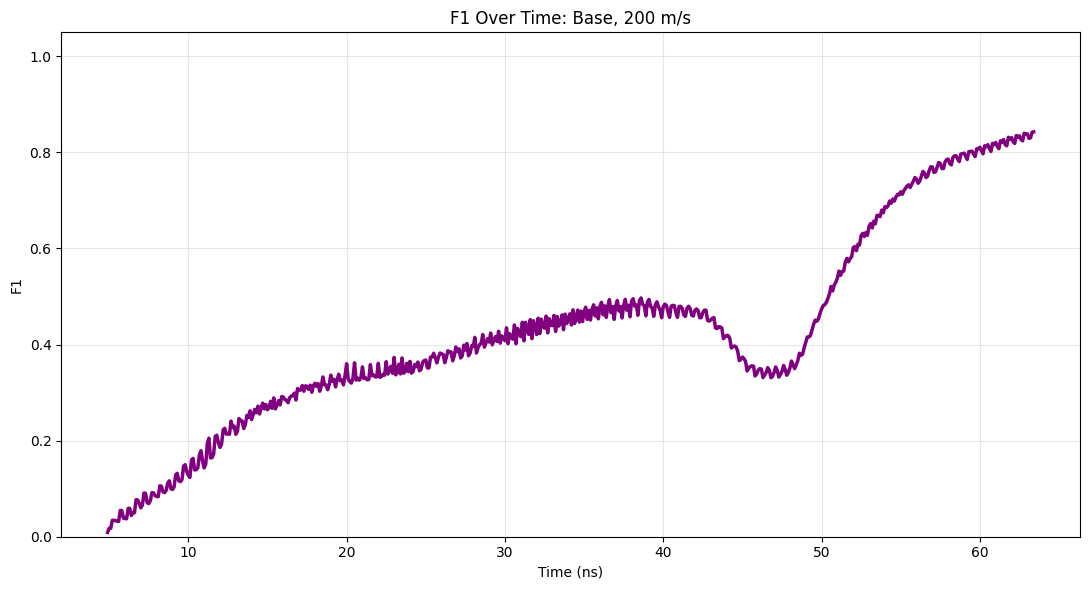

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/individual_f1_plots/f1_over_time_base_200_m_s.png


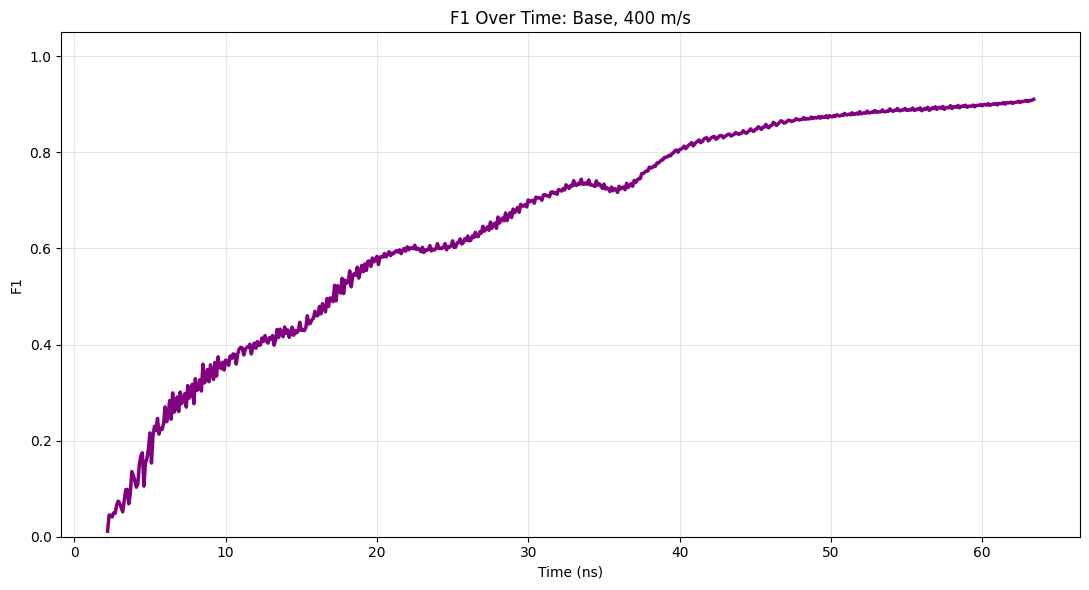

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/individual_f1_plots/f1_over_time_base_400_m_s.png


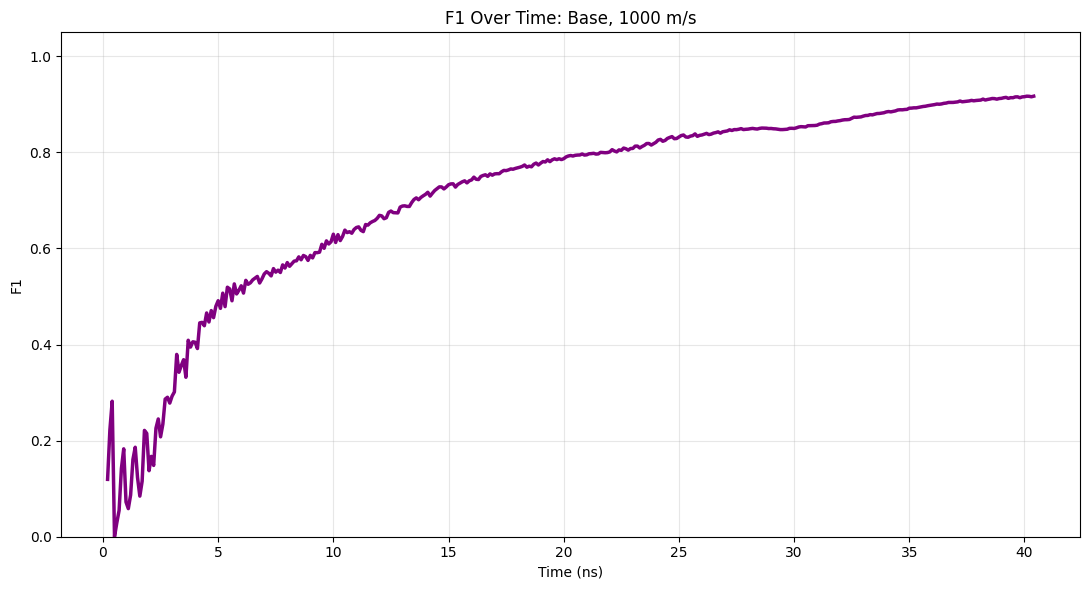

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/individual_f1_plots/f1_over_time_base_1000_m_s.png


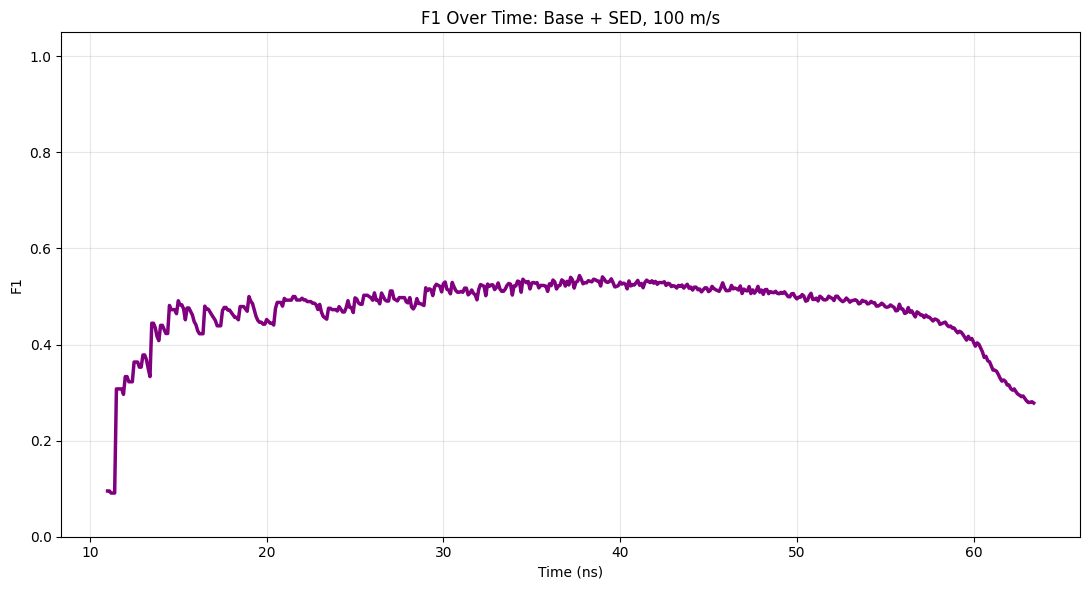

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/individual_f1_plots/f1_over_time_base_plus_sed_100_m_s.png


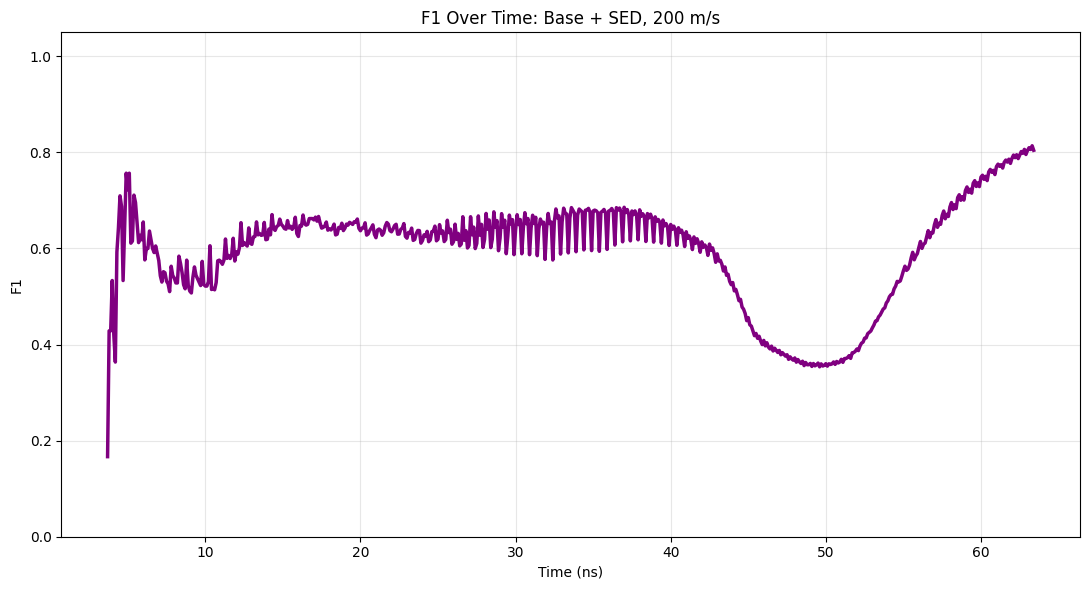

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/individual_f1_plots/f1_over_time_base_plus_sed_200_m_s.png


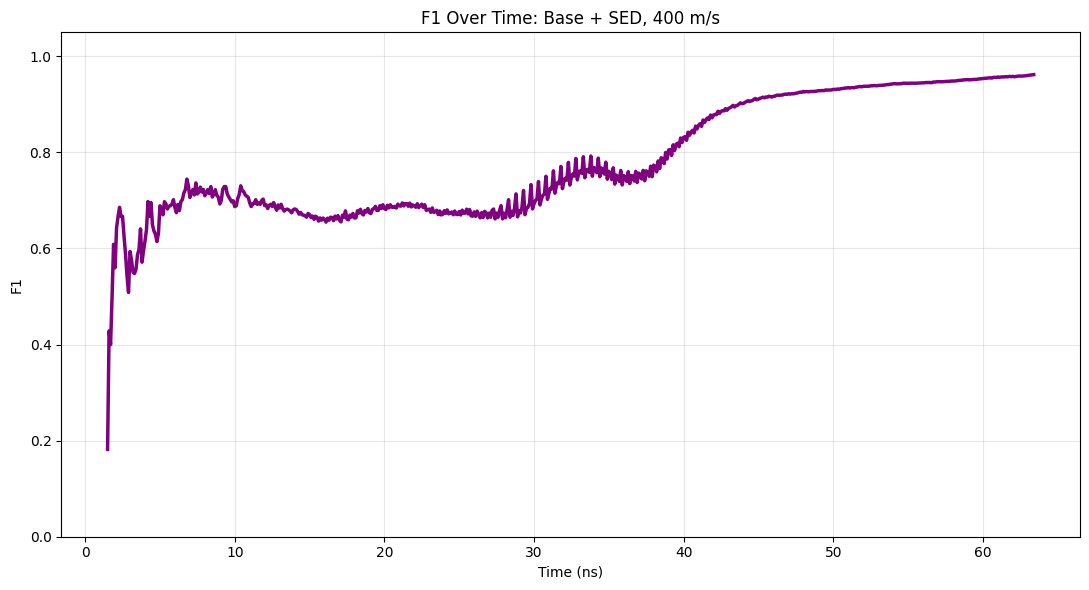

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/individual_f1_plots/f1_over_time_base_plus_sed_400_m_s.png


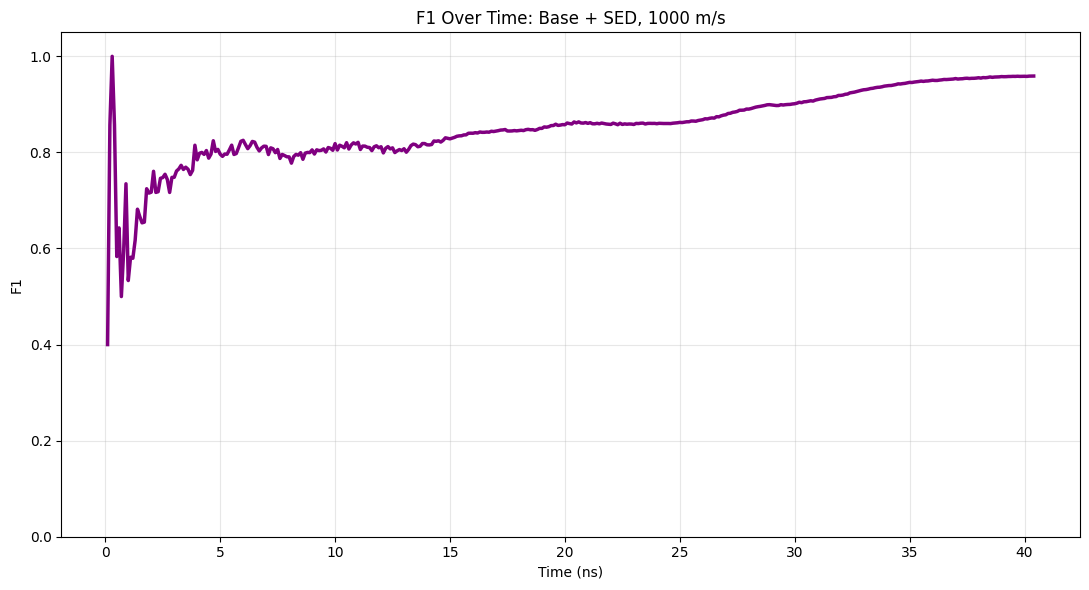

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR_horizontal/individual_f1_plots/f1_over_time_base_plus_sed_1000_m_s.png


In [426]:
info = pcfs.plot_f1_full_simulation_comparison(
    csv_map=csv_map,
    out_dir=out_dir,
    show=True,
    linewidth=2.5,
    colors_all=["blue", "tomato", "green", "darkviolet", "dodgerblue", "lightsalmon", "limegreen", "violet"],
    colors_base=["blue", "lightsalmon", "green", "darkviolet"],
    colors_sed=["dodgerblue", "red", "limegreen", "violet"],
    individual_color="purple",
    time_scale=1
)

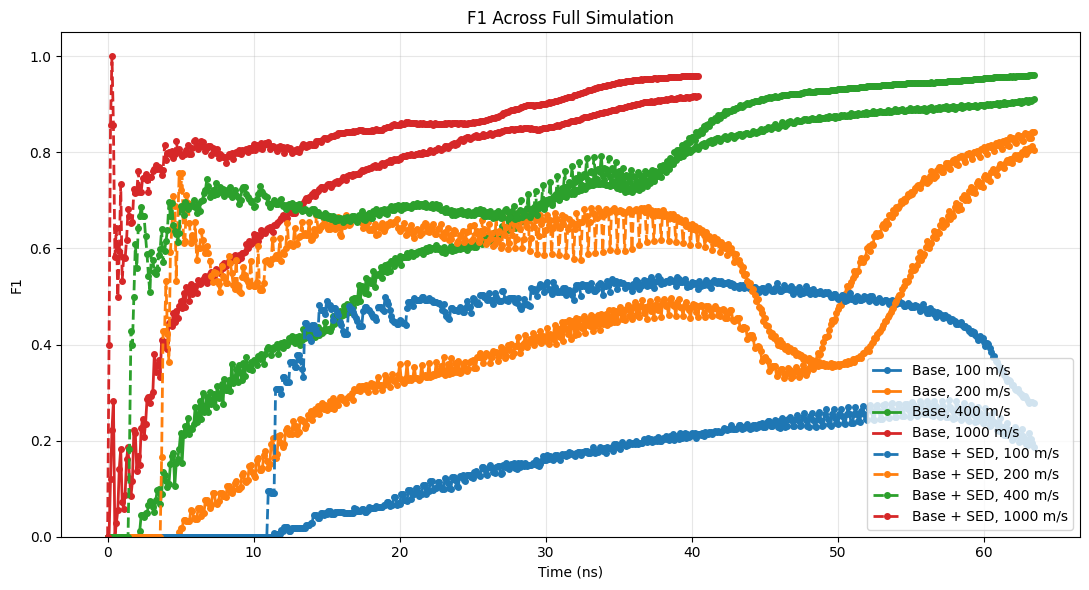

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_comparison.png


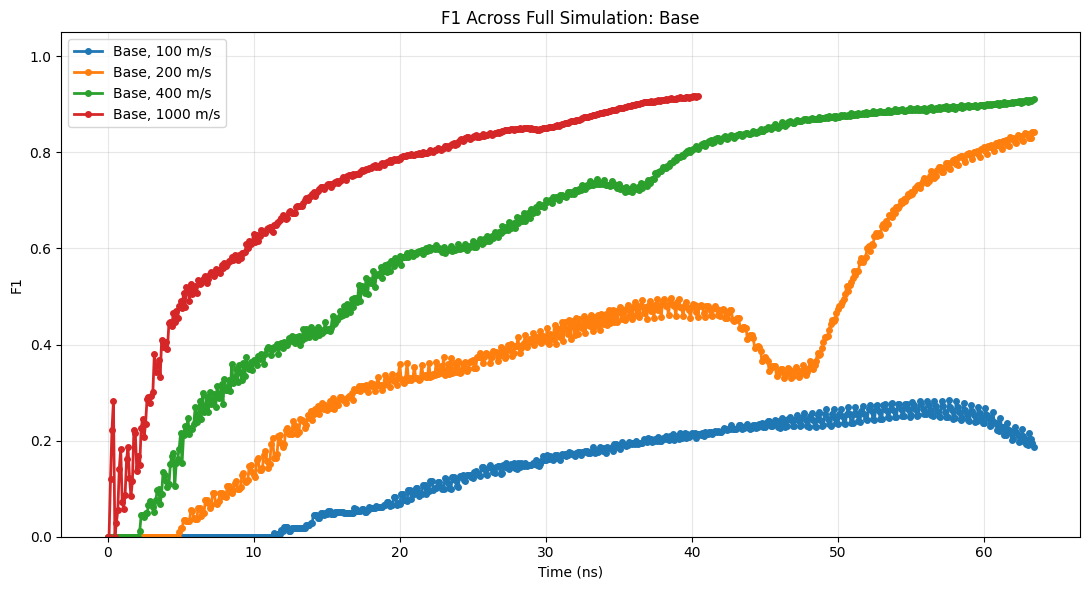

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_base_only.png


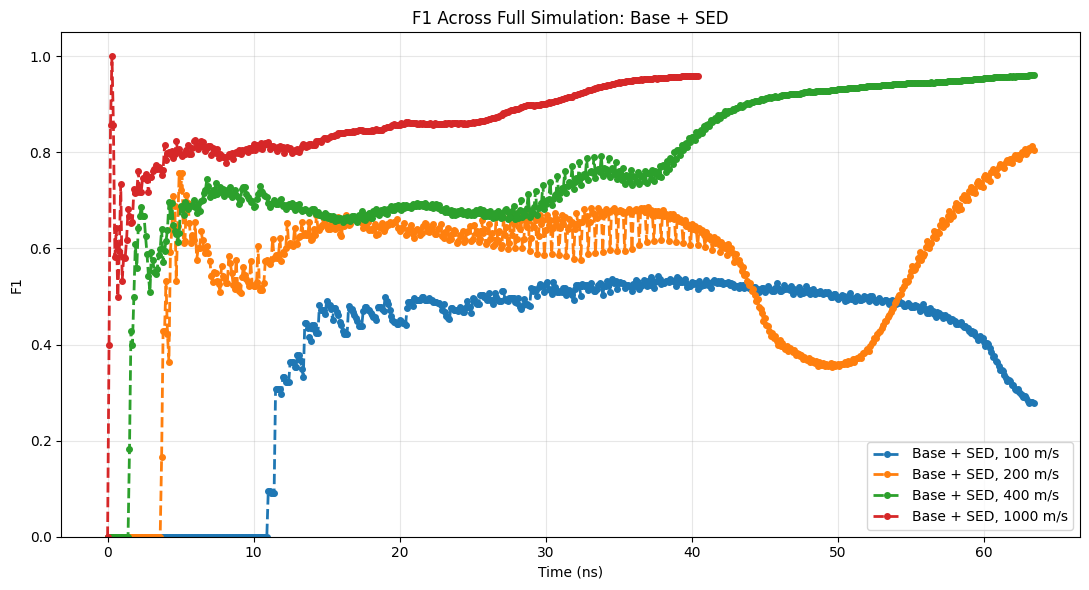

Saved plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_base_plus_sed_only.png


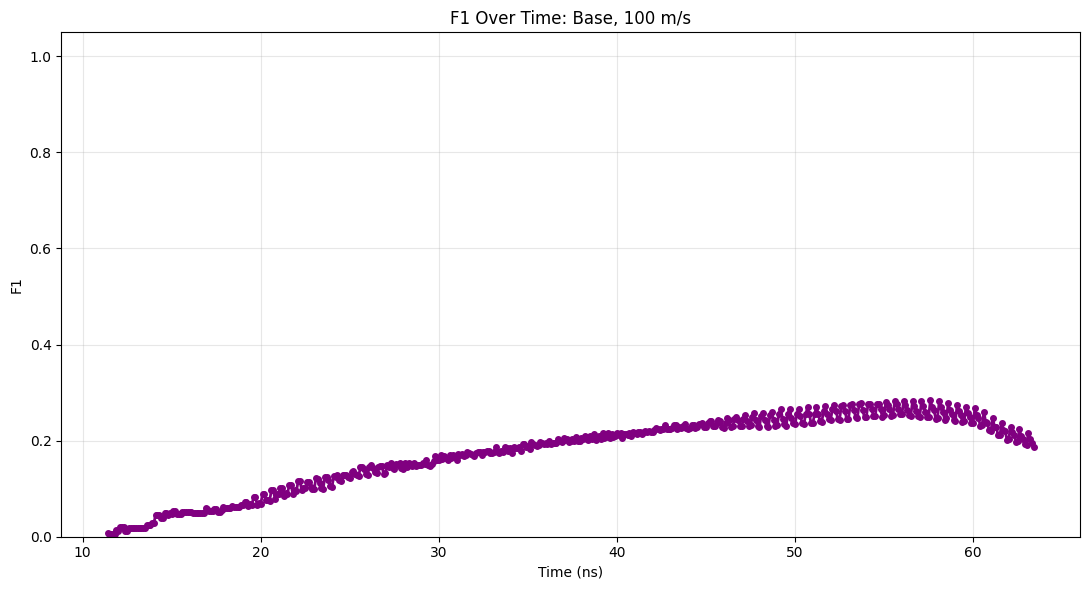

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_100_m_s.png


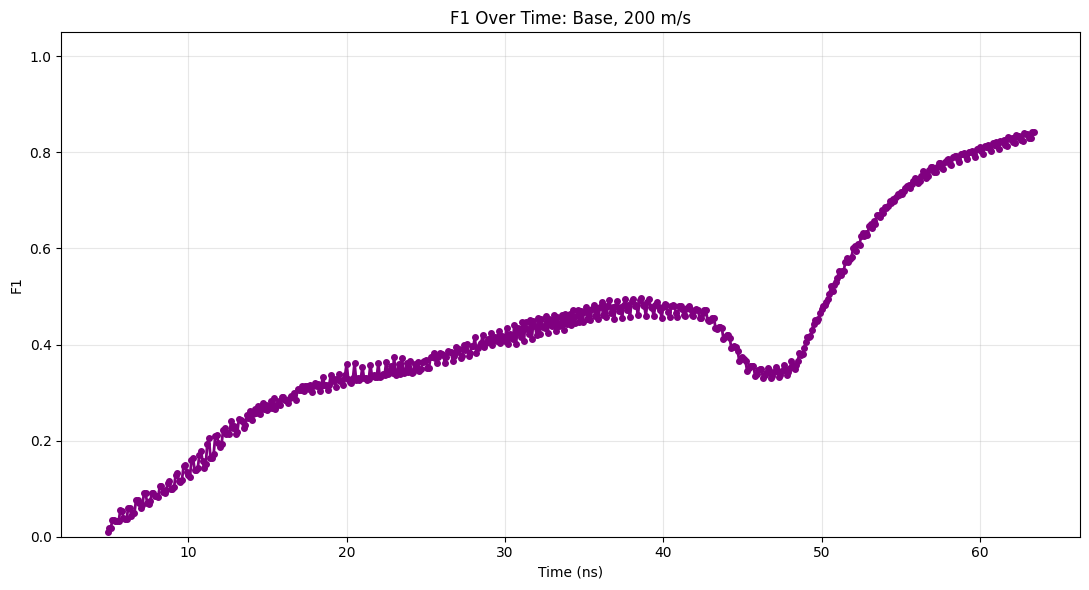

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_200_m_s.png


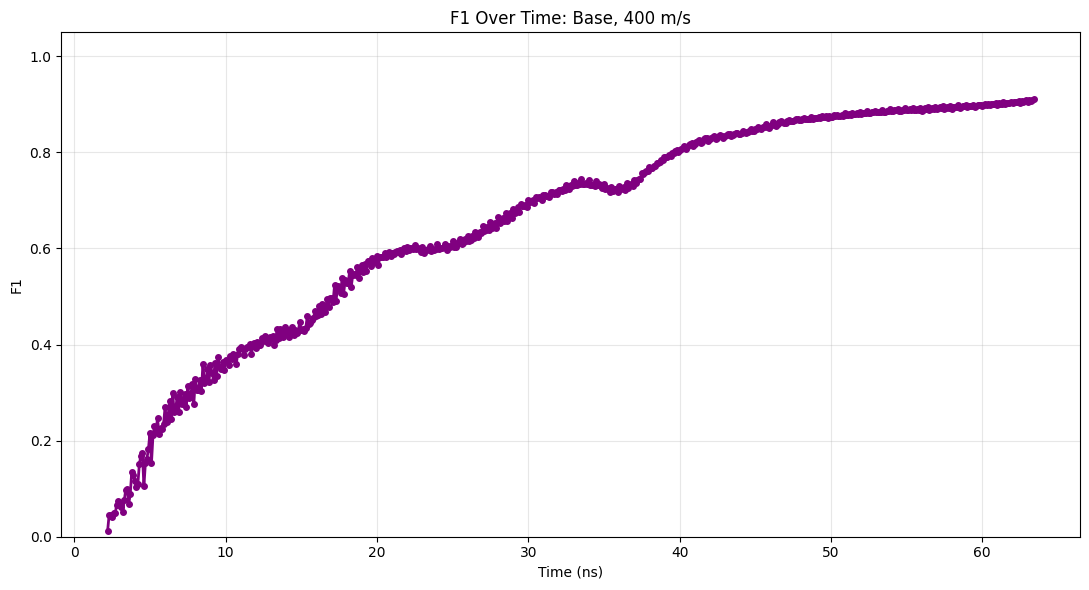

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_400_m_s.png


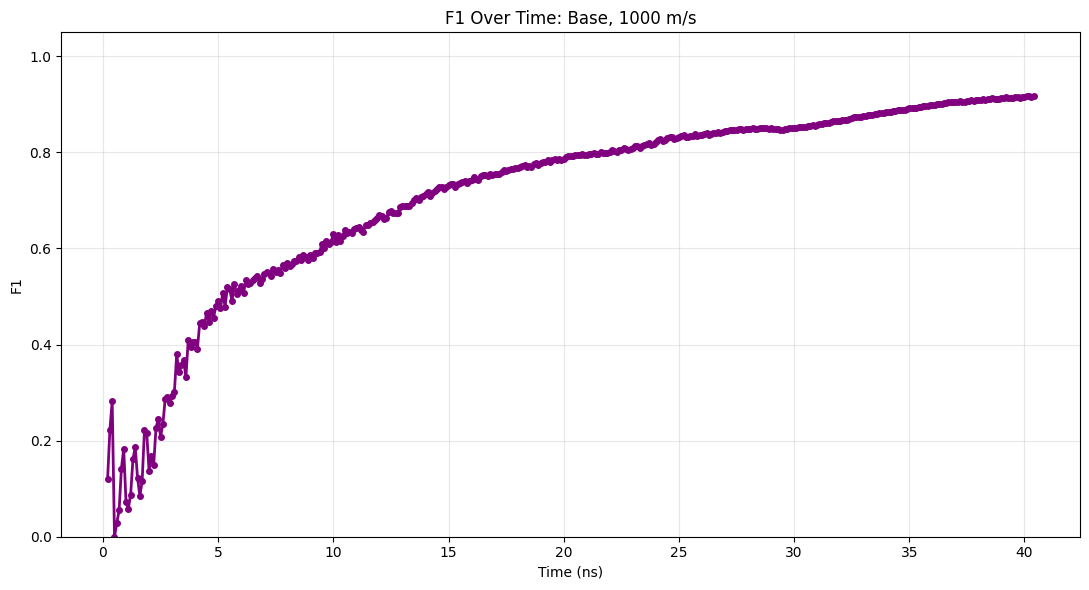

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_1000_m_s.png


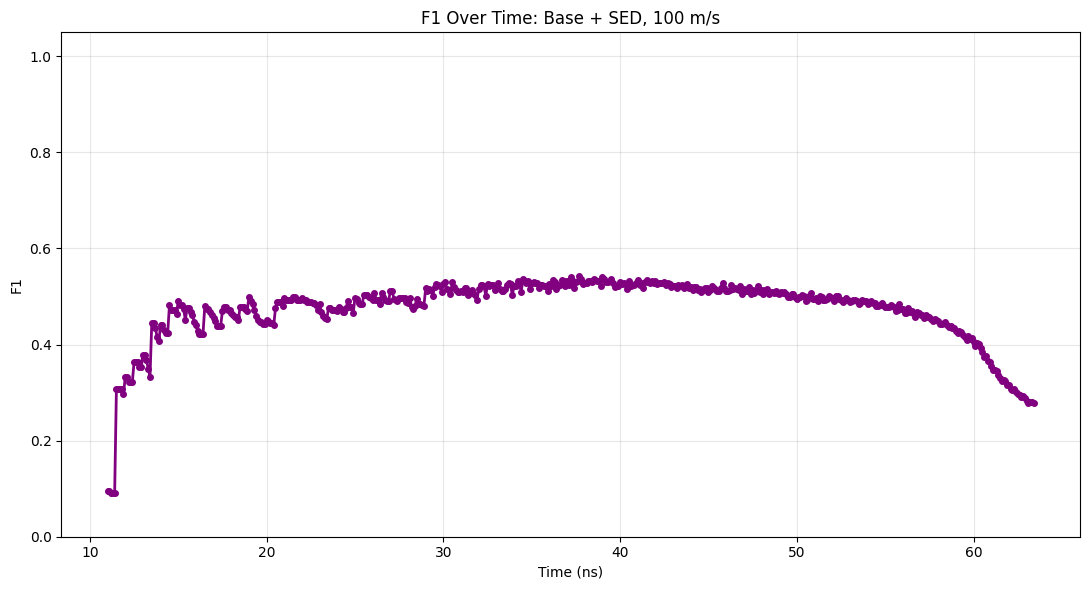

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_plus_sed_100_m_s.png


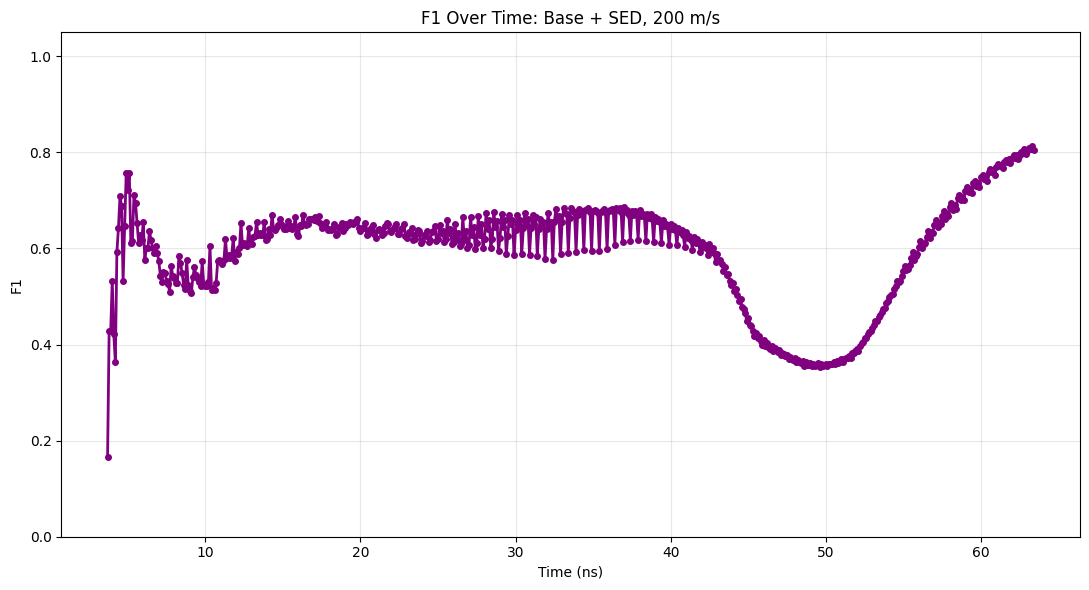

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_plus_sed_200_m_s.png


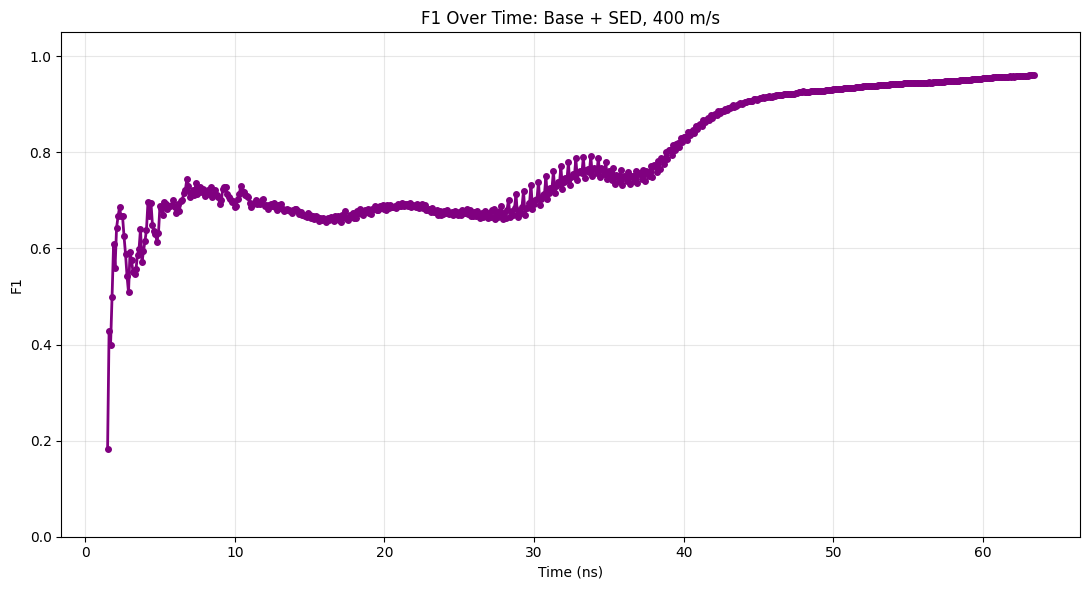

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_plus_sed_400_m_s.png


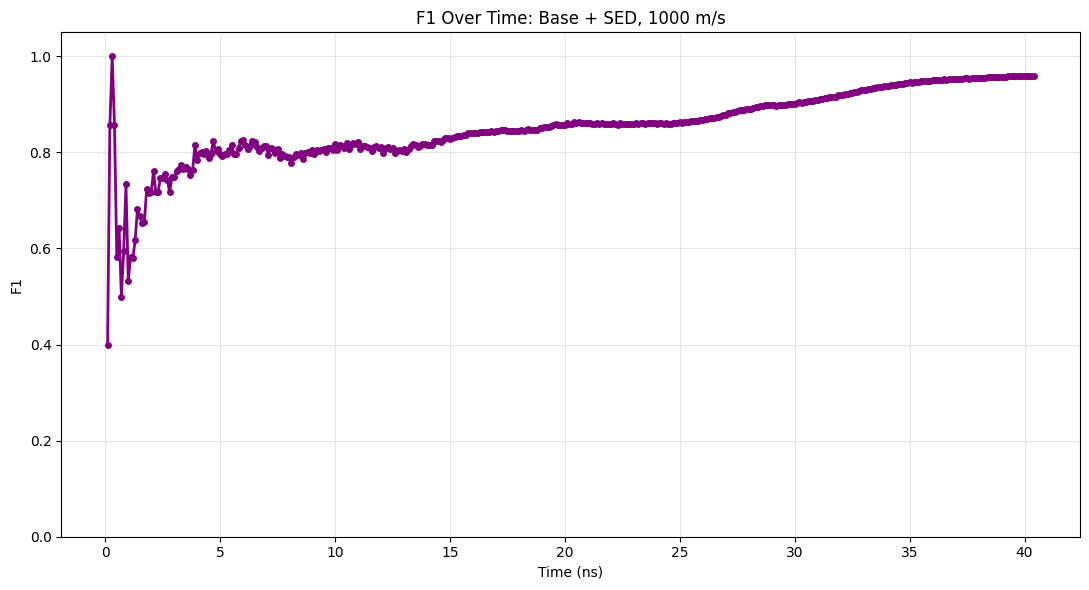

Saved individual plot to: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_plus_sed_1000_m_s.png


{'all_plot_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_comparison.png',
 'base_plot_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_base_only.png',
 'base_plus_sed_plot_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR/f1_full_simulation_base_plus_sed_only.png',
 'individual_plot_dir': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots',
 'individual_plot_count': 8,
 'individual_plot_info': [{'model': 'Base',
   'velocity': '100 m/s',
   'csv_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/VISUALS/Prediction_Binary_Masks/SimMic_BASE/test_MS206_V100/per_frame_metrics.csv',
   'plot_path': '/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots/f1_over_time_base_100_m_s.png',
   'started_from_positive_f1': True},
  {'model': 'Base',
   '

In [371]:
info = pcfs.plot_f1_full_simulation_comparison(
    csv_map=csv_map,
    out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare_AR",
    individual_out_dir="/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/f1_compare/individual_plots",
    time_scale=1.0,
    show=True,
)

info

## Plotting loss

In [140]:
# Path for the csv training log you want to plot
#csv1 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/pressure_20260215_182728/training_log.csv"
#csv2 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/pressure_20260216_120602/training_log.csv"
#csv3 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS//MODEL/pressure_20260216_173723/training_log.csv"




#csv1 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/vonmises_20260215_183351/training_log.csv"
#csv2 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/vonmises_20260216_121240/training_log.csv"
#csv3 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS//MODEL/vonmises_20260216_185538/training_log.csv"

csv1 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/sed_20260215_183409/training_log.csv"
csv2 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS/MODEL/sed_20260216_121259/training_log.csv"
csv3 = "/scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_INPUTS//MODEL/sed_20260216_185557/training_log.csv"

#csv1 = "/scratch/gilbreth/kmartinu/microML/training_log_undef.csv"


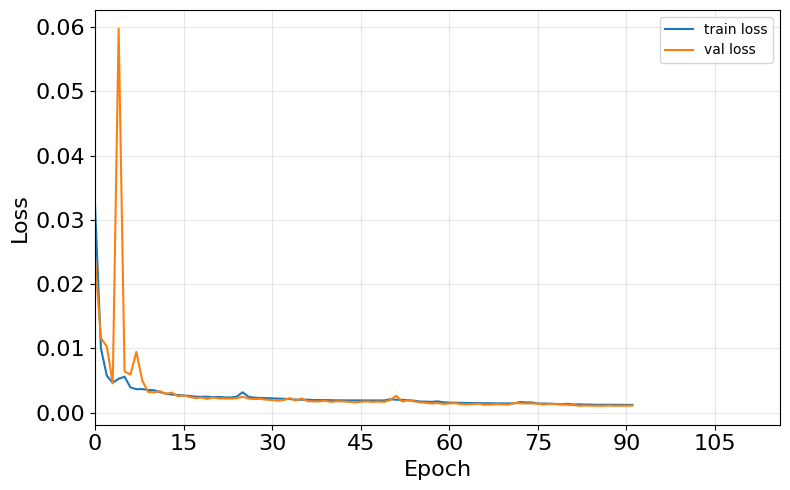

Saved: /scratch/gilbreth/kmartinu/MICROSTRUCTURE_ML/ALL_OUTPUTS/METRICS/sed_20260215_183409/train_val_loss.png


In [141]:
out = lc.plot_loss_curves_to_metrics(
    [csv1, csv2, csv3],#[csv1, csv2, csv3],
    append_csvs=True,
    max_epoch=116,
    title="",
    n_xticks=10,
    title_fontsize=22,
    label_fontsize=16,
    tick_fontsize=16,
    legend_fontsize=16,
    show=True,
)


print("Saved:", out)